# Analisis Exploratorio y Modelado - Sleep Health Dataset

**Proyecto CRISP-DM** aplicado al dataset `sleep_health_dataset.csv` (100,000 filas, 32 columnas).

**Variable objetivo:** `sleep_disorder_risk` (multiclase: Healthy / Mild / Moderate / Severe)

**Notas de adaptacion respecto al notebook original (Social Media Impact):**
- Dataset 58x mas grande (1,705 -> 100,000 filas), por eso para CV pesado usamos **muestra estratificada de 20,000 filas** (ver Seccion 5).
- Reemplazos por velocidad: `SVC(rbf)` -> `LinearSVC`, `GradientBoostingClassifier` -> `HistGradientBoostingClassifier`.
- `n_jobs=-1` en todos los modelos que lo soportan.
- Seccion 8 compara modelo sin `sleep_quality_score` (feature mas predictiva, analoga a `Mental_Health_Score`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
print('Imports OK')


Imports OK


## 2. Carga de Datos

In [2]:
# Ajusta la ruta segun tu entorno (Colab/local)
CSV_PATH = 'sleep_health_dataset.csv'
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [3]:
print('=== INFORMACION DEL DATASET ===')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Memoria: {df.memory_usage(deep=True).sum()/1e6:.2f} MB')
df.info()


=== INFORMACION DEL DATASET ===
Filas: 100,000
Columnas: 32
Memoria: 63.55 MB
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64

## 3. FASE 2 CRISP-DM - Comprension de los Datos (EDA)

### 3.1 Estructura General

In [4]:
print('=== ESTRUCTURA GENERAL ===')
print(f'Tipos de datos:')
print(df.dtypes.value_counts())
print('\n=== Columnas numericas ===')
print(df.select_dtypes(include=[np.number]).columns.tolist())
print('\n=== Columnas categoricas ===')
print(df.select_dtypes(include=['object']).columns.tolist())


=== ESTRUCTURA GENERAL ===
Tipos de datos:
int64      13
float64    11
str         8
Name: count, dtype: int64

=== Columnas numericas ===
['person_id', 'age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']

=== Columnas categoricas ===
['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']


### 3.2 Estadisticas Descriptivas

In [5]:
print('=== NUMERICAS ===')
df.describe().T


=== NUMERICAS ===


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0


In [6]:
print('=== CATEGORICAS ===')
df.describe(include='object').T


=== CATEGORICAS ===


,count,unique,top,freq
gender,100000,3,Female,50203
occupation,100000,12,Student,14851
country,100000,15,USA,20050
chronotype,100000,3,Neutral,45396
mental_health_condition,100000,4,Healthy,69993
season,100000,4,Summer,25121
day_type,100000,2,Weekday,71428
sleep_disorder_risk,100000,4,Healthy,54156


### 3.3 Valores Nulos y Duplicados

In [7]:
print('=== NULOS ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'Sin valores nulos.')
print(f'\nDuplicados: {df.duplicated().sum()}')


=== NULOS ===
Sin valores nulos.

Duplicados: 0


### 3.4 Variable Target: sleep_disorder_risk

=== TARGET DISTRIBUTION ===
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

Proporciones:
sleep_disorder_risk
Healthy     54.16
Mild        33.48
Moderate     8.30
Severe       4.07
Name: proportion, dtype: float64


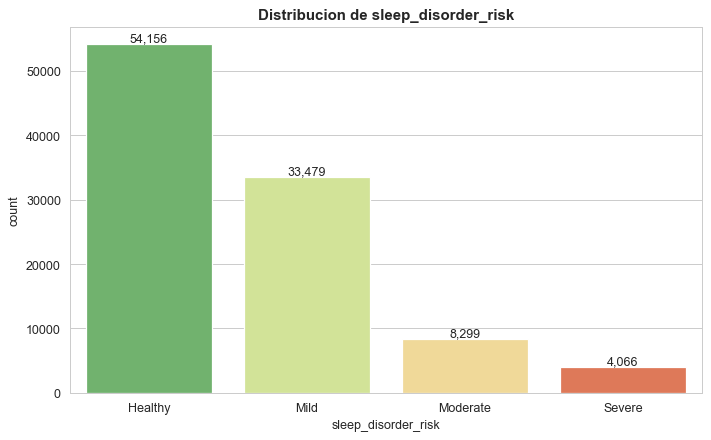

In [8]:
target = 'sleep_disorder_risk'
print('=== TARGET DISTRIBUTION ===')
print(df[target].value_counts())
print('\nProporciones:')
print((df[target].value_counts(normalize=True)*100).round(2))

fig, ax = plt.subplots(figsize=(8,5))
order = ['Healthy', 'Mild', 'Moderate', 'Severe']
sns.countplot(data=df, x=target, order=order, palette='RdYlGn_r', ax=ax)
ax.set_title('Distribucion de sleep_disorder_risk', fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()


### 3.5 Distribuciones Numericas Clave

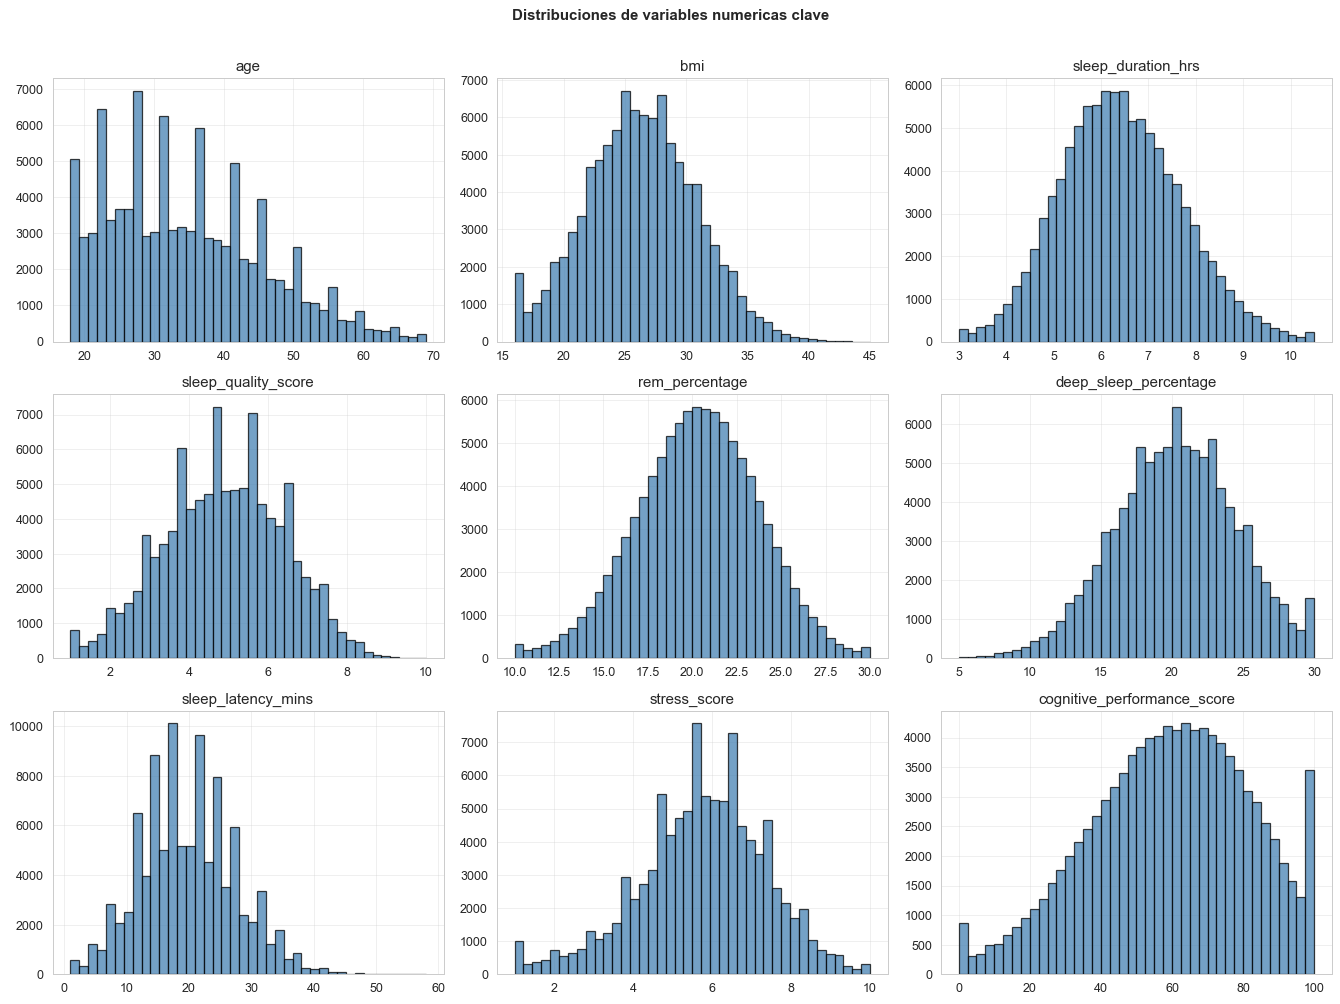

In [9]:
numeric_key = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
               'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
               'stress_score', 'cognitive_performance_score']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), numeric_key):
    ax.hist(df[col], bins=40, alpha=0.75, color='steelblue', edgecolor='black')
    ax.set_title(col); ax.grid(alpha=0.3)
plt.suptitle('Distribuciones de variables numericas clave', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 3.6 Distribuciones Categoricas

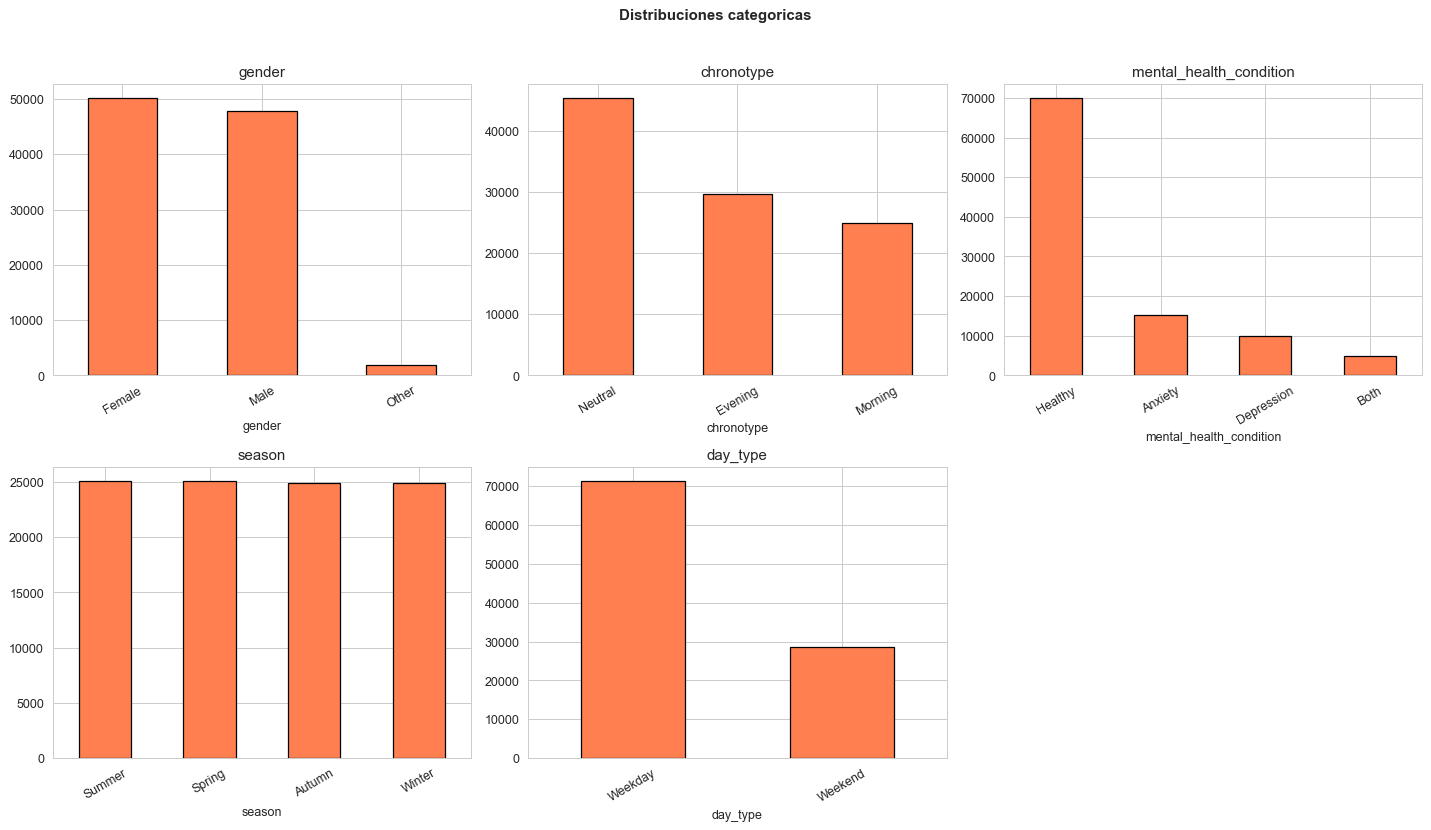


Ocupaciones (top 15):
occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64

Paises unicos: 15


In [10]:
cat_cols = ['gender', 'chronotype', 'mental_health_condition', 'season', 'day_type']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(col); axes[i].tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.suptitle('Distribuciones categoricas', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\nOcupaciones (top 15):')
print(df['occupation'].value_counts().head(15))
print(f'\nPaises unicos: {df["country"].nunique()}')


### 3.7 Analisis Bivariado vs Target

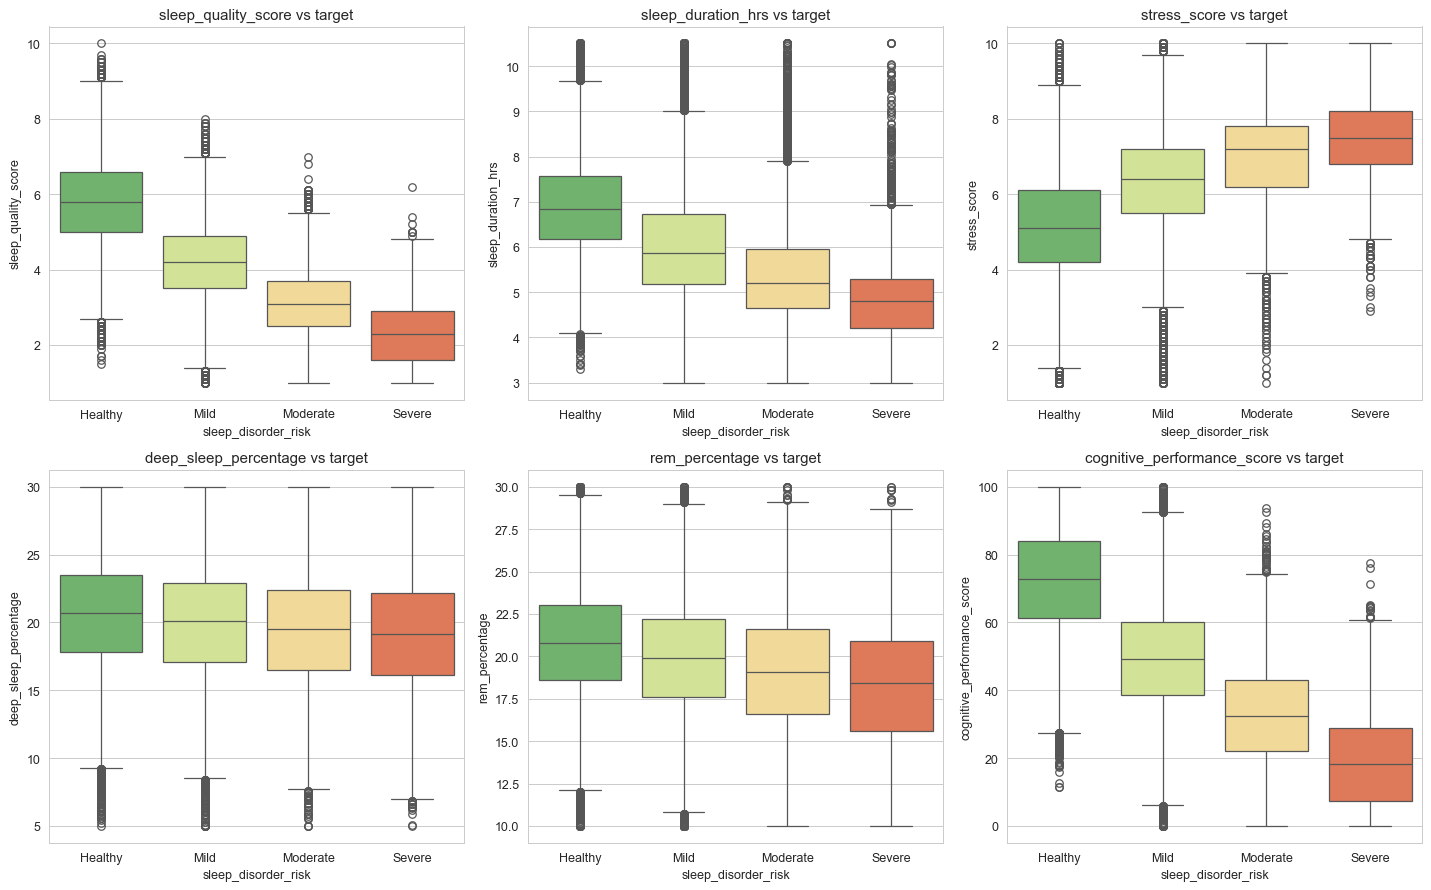

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
order = ['Healthy', 'Mild', 'Moderate', 'Severe']
for ax, col in zip(axes.ravel(),
    ['sleep_quality_score', 'sleep_duration_hrs', 'stress_score',
     'deep_sleep_percentage', 'rem_percentage', 'cognitive_performance_score']):
    sns.boxplot(data=df, x=target, y=col, order=order, palette='RdYlGn_r', ax=ax)
    ax.set_title(f'{col} vs target')
plt.tight_layout(); plt.show()


### 3.8 Correlaciones (numericas vs target codificado)

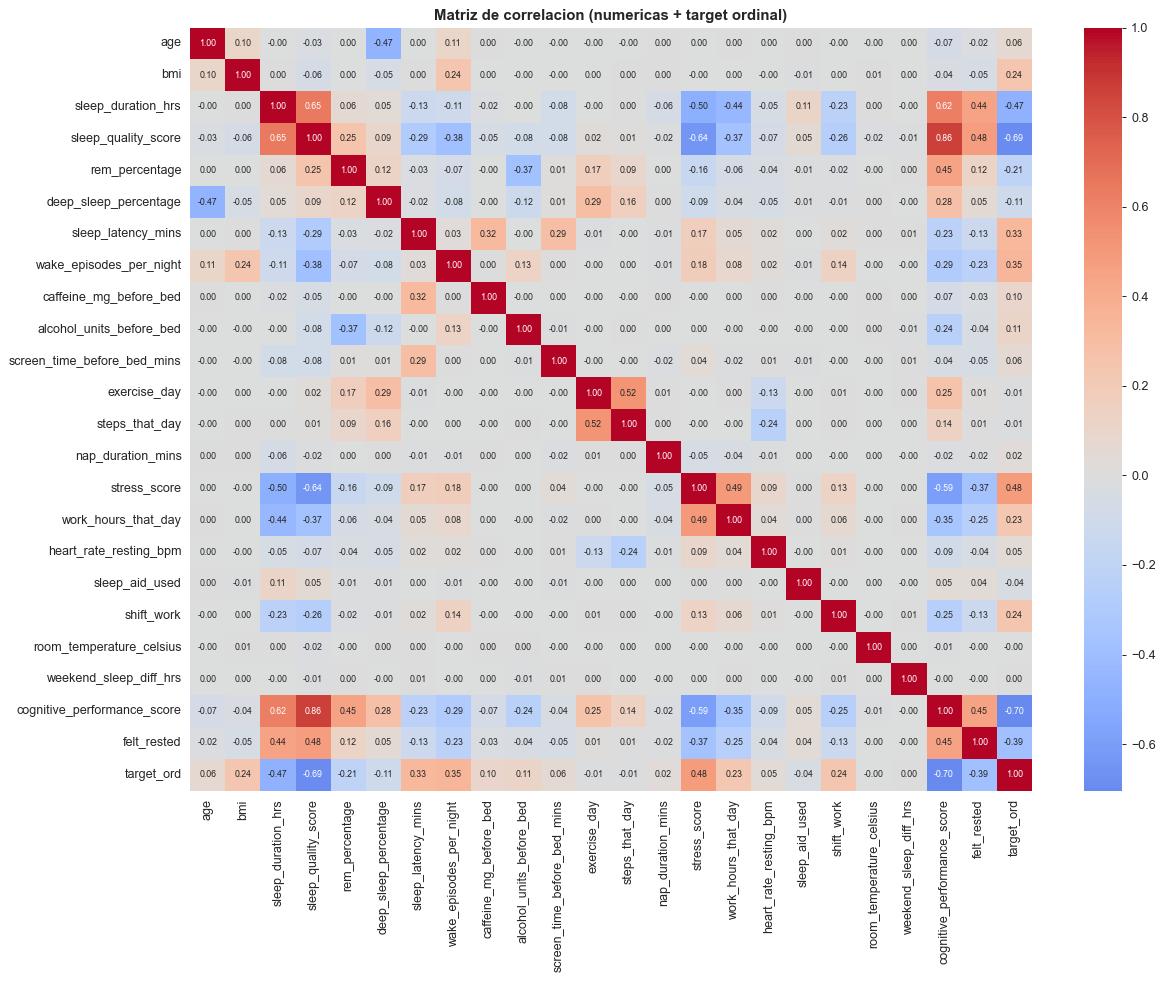


Top 10 correlaciones con target:
cognitive_performance_score    0.703790
sleep_quality_score            0.693763
stress_score                   0.483752
sleep_duration_hrs             0.473561
felt_rested                    0.387377
wake_episodes_per_night        0.346527
sleep_latency_mins             0.332583
shift_work                     0.241010
bmi                            0.236847
work_hours_that_day            0.228350
Name: target_ord, dtype: float64


In [12]:
df_corr = df.copy()
le_tmp = LabelEncoder()
# Forzar orden ordinal del riesgo
risk_order = {'Healthy':0, 'Mild':1, 'Moderate':2, 'Severe':3}
df_corr['target_ord'] = df_corr[target].map(risk_order)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'person_id']
corr = df_corr[num_cols + ['target_ord']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size':7}, ax=ax)
ax.set_title('Matriz de correlacion (numericas + target ordinal)', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop 10 correlaciones con target:')
print(corr['target_ord'].drop('target_ord').abs().sort_values(ascending=False).head(10))


### 3.9 Outliers (IQR)

In [13]:
print('=== OUTLIERS DETECCION (IQR) ===')
out_summary = []
for col in numeric_key:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    out_summary.append((col, n_out, n_out/len(df)*100))
out_df = pd.DataFrame(out_summary, columns=['variable','n_outliers','pct'])
print(out_df.to_string(index=False))


=== OUTLIERS DETECCION (IQR) ===
                   variable  n_outliers   pct
                        age         341 0.341
                        bmi         341 0.341
         sleep_duration_hrs         545 0.545
        sleep_quality_score          12 0.012
             rem_percentage         778 0.778
      deep_sleep_percentage         402 0.402
         sleep_latency_mins         368 0.368
               stress_score        2153 2.153
cognitive_performance_score           0 0.000


### 3.10 Hallazgos Clave del EDA

- Dataset **balanceado en filas** (100k) pero **desbalanceado en target**: ~54% Healthy, 33% Mild, 8% Moderate, 4% Severe.
- Sin nulos ni duplicados.
- Variables mas correlacionadas con riesgo: a confirmar tras `df_corr` (probablemente `sleep_quality_score`, `deep_sleep_percentage`, `stress_score`).
- `country` y `occupation` tienen muchas categorias -> OneHotEncoder generara muchas columnas; considerar agrupar o usar target encoding si fuera necesario.
- `person_id` se descarta (identificador).


## 4. FASE 3 CRISP-DM - Preparacion de Datos

### 4.1 Decisiones de Preprocesamiento

- **Drop:** `person_id` (identificador, no aporta).
- **Target:** `sleep_disorder_risk` codificado con `LabelEncoder` (orden Healthy<Mild<Moderate<Severe).
- **Numericas:** se escalan con `StandardScaler`.
- **Ordinal:** `chronotype` (Morning < Neutral < Evening).
- **Nominales:** `gender, occupation, country, mental_health_condition, season, day_type` con `OneHotEncoder(drop='if_binary')`.
- **Binarias enteras** (`exercise_day, sleep_aid_used, shift_work, felt_rested`) se tratan como numericas (ya estan 0/1).
- Estratificamos el split por target.


### 4.2 Limpieza Inicial

In [14]:
df_prep = df.drop(columns=['person_id']).copy()
print(f'Shape tras drop: {df_prep.shape}')


Shape tras drop: (100000, 31)


### 4.3 Encoding del Target

In [15]:
le = LabelEncoder()
# Forzar orden Healthy<Mild<Moderate<Severe
le.classes_ = np.array(['Healthy', 'Mild', 'Moderate', 'Severe'])
y = pd.Series(le.transform(df_prep[target]), name=target)
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print(y.value_counts().sort_index())


Mapping: {np.str_('Healthy'): np.int64(0), np.str_('Mild'): np.int64(1), np.str_('Moderate'): np.int64(2), np.str_('Severe'): np.int64(3)}
sleep_disorder_risk
0    54156
1    33479
2     8299
3     4066
Name: count, dtype: int64


### 4.4 Separacion Train/Test (estratificada)

In [16]:
X = df_prep.drop(columns=[target])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train dist:\n{pd.Series(y_train).value_counts(normalize=True).round(3).sort_index()}')


X_train: (80000, 30) | X_test: (20000, 30)
y_train dist:
sleep_disorder_risk
0    0.542
1    0.335
2    0.083
3    0.041
Name: proportion, dtype: float64


### 4.5 Pipeline ColumnTransformer

In [17]:
numeric_feat = [
    'age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
    'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
    'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed',
    'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day',
    'nap_duration_mins', 'stress_score', 'work_hours_that_day',
    'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
    'room_temperature_celsius', 'weekend_sleep_diff_hrs',
    'cognitive_performance_score', 'felt_rested'
]
ordinal_feat = ['chronotype']
nominal_feat = ['gender', 'occupation', 'country', 'mental_health_condition', 'season', 'day_type']

assert set(numeric_feat + ordinal_feat + nominal_feat) == set(X_train.columns), \
    f'Faltan/sobran columnas: {set(X_train.columns) ^ set(numeric_feat+ordinal_feat+nominal_feat)}'

num_trans = Pipeline([('scaler', StandardScaler())])
ord_trans = Pipeline([('enc', OrdinalEncoder(
    categories=[['Morning', 'Neutral', 'Evening']],
    handle_unknown='use_encoded_value', unknown_value=-1
))])
nom_trans = Pipeline([('enc', OneHotEncoder(
    handle_unknown='ignore', sparse_output=False, drop='if_binary'
))])

preprocessor = ColumnTransformer([
    ('num', num_trans, numeric_feat),
    ('ord', ord_trans, ordinal_feat),
    ('nom', nom_trans, nominal_feat)
])
print('Pipeline construido')


Pipeline construido


In [18]:
print('Ajustando preprocessor...')
t0 = time.time()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print(f'Tiempo: {time.time()-t0:.2f}s')
print(f'X_train procesado: {X_train_proc.shape}')
print(f'X_test  procesado: {X_test_proc.shape}')


Ajustando preprocessor...
Tiempo: 0.16s
X_train procesado: (80000, 63)
X_test  procesado: (20000, 63)


### 4.6 Resumen Final

In [19]:
print('='*70)
print('RESUMEN FINAL'.center(70))
print('='*70)
print(f'\nDataset original: {df.shape}')
print(f'X_train: {X_train_proc.shape}')
print(f'X_test : {X_test_proc.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'Clases: {list(le.classes_)}')


                            RESUMEN FINAL                             

Dataset original: (100000, 32)
X_train: (80000, 63)
X_test : (20000, 63)
y_train: (80000,) | y_test: (20000,)
Clases: [np.str_('Healthy'), np.str_('Mild'), np.str_('Moderate'), np.str_('Severe')]


### 4.7 Exportar

In [20]:
os.makedirs('preprocesados', exist_ok=True)
np.save('preprocesados/X_train.npy', X_train_proc)
np.save('preprocesados/X_test.npy',  X_test_proc)
np.save('preprocesados/y_train.npy', y_train.values)
np.save('preprocesados/y_test.npy',  y_test.values)
joblib.dump(preprocessor, 'preprocesados/pipeline.pkl')
joblib.dump(le, 'preprocesados/label_encoder.pkl')
print('Datos exportados a preprocesados/')


Datos exportados a preprocesados/


### 4.8 Comparacion StandardScaler vs MinMaxScaler (baseline)

In [21]:
# Pipeline alternativo con MinMaxScaler
preprocessor_mm = ColumnTransformer([
    ('num', Pipeline([('scaler', MinMaxScaler())]), numeric_feat),
    ('ord', ord_trans, ordinal_feat),
    ('nom', nom_trans, nominal_feat)
])
X_train_mm = preprocessor_mm.fit_transform(X_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
from sklearn.linear_model import LogisticRegression

print('Comparacion baseline (LogisticRegression, 5-Fold CV):')
for name, Xt in [('StandardScaler', X_train_proc), ('MinMaxScaler', X_train_mm)]:
    t0 = time.time()
    sc = cross_val_score(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                           class_weight='balanced', n_jobs=-1),
        Xt, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1
    )
    print(f'  {name:<15} F1w={sc.mean():.4f} (+/-{sc.std():.4f})  [{time.time()-t0:.1f}s]')


Comparacion baseline (LogisticRegression, 5-Fold CV):
  StandardScaler  F1w=0.8138 (+/-0.0031)  [4.6s]
  MinMaxScaler    F1w=0.8134 (+/-0.0031)  [4.9s]


## 5. FASE 4 CRISP-DM - Modelado

Comparamos 8 clasificadores con el flujo metodologicamente riguroso:

1. **Definir** los 8 clasificadores y sus grids de hiperparametros.
2. **GridSearchCV** sobre cada uno (5-fold sobre muestra de 20k) para encontrar la mejor configuracion.
3. **Validacion cruzada final 10-Fold** con los modelos ya optimizados → ranking justo.
4. **Evaluacion en test set completo** (20k filas) y export del mejor.

**Nota sobre escala**: con 100k filas, el GridSearch+CV completo seria inviable (horas).
Se usa muestra estratificada de 20k para tuning y CV; el test final usa el conjunto completo.

**Reemplazos por rendimiento vs sklearn original**: `SVC(rbf)`→`LinearSVC`, `GradientBoosting`→`HistGradientBoosting`, `n_jobs=-1` donde aplica.


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.base import clone
from statistics import mean, stdev
import itertools

# === Muestra estratificada de 20k para tuning + CV ===
SAMPLE_SIZE = 20000
from sklearn.model_selection import train_test_split as _tts
_, X_cv_idx, _, y_cv = _tts(
    np.arange(len(y_train)), y_train,
    test_size=SAMPLE_SIZE, random_state=RANDOM_STATE, stratify=y_train
)
X_cv = X_train_proc[X_cv_idx]
y_cv = y_cv.values if hasattr(y_cv, 'values') else np.asarray(y_cv)
print(f'Muestra: X={X_cv.shape}, y={y_cv.shape}')
print(f'Distribucion: {pd.Series(y_cv).value_counts(normalize=True).round(3).to_dict()}')


Muestra: X=(20000, 63), y=(20000,)
Distribucion: {0: 0.542, 1: 0.335, 2: 0.083, 3: 0.041}


### 5.1 Funcion de Cross-Validation con Progreso

In [23]:
def cvClassifiers(X, Y, list_Classifiers, names, n_splits=10, verbose=True):
    """Stratified K-Fold CV con prints de progreso por clasificador."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    folds = list(skf.split(X, Y))

    scores = [[] for _ in list_Classifiers]
    pred_y = [[] for _ in list_Classifiers]
    real_y = [[] for _ in list_Classifiers]
    times  = [0.0]*len(list_Classifiers)

    for i, c in enumerate(list_Classifiers):
        t0 = time.time()
        for train_idx, test_idx in folds:
            model = clone(c)
            model.fit(X[train_idx], Y[train_idx])
            scores[i].append(model.score(X[test_idx], Y[test_idx]))
            py = model.predict(X[test_idx])
            pred_y[i].extend(py.tolist())
            real_y[i].extend(Y[test_idx].tolist())
        times[i] = time.time() - t0
        if verbose:
            print(f'  [{i+1}/{len(list_Classifiers)}] {names[i]:<25} '
                  f'acc={mean(scores[i])*100:5.2f}%  ({times[i]:.1f}s)')

    accuracy = [mean(s)*100 for s in scores]
    cm = [confusion_matrix(real_y[i], pred_y[i]) for i in range(len(list_Classifiers))]
    return accuracy, cm, scores, times

print('Funcion cvClassifiers definida')


Funcion cvClassifiers definida


### 5.2 Definicion de Modelos Base y Grids de Hiperparametros

Listamos los 8 clasificadores junto con sus grids. **Aun no entrenamos** — eso ocurre en 5.3.


In [24]:
nombres_clf = [
    'KNN', 'Naive Bayes', 'Logistic Regression', 'Decision Tree',
    'LinearSVC', 'Random Forest', 'HistGradientBoosting', 'AdaBoost'
]

base_models = {
    'KNN': KNeighborsClassifier(n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000, n_jobs=-1,
                              class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE,
                              class_weight='balanced'),
    'LinearSVC': LinearSVC(random_state=RANDOM_STATE, class_weight='balanced',
                              max_iter=3000, dual='auto'),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE,
                              class_weight='balanced', n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

# Grids compactos (3-6 combinaciones por modelo) para mantener tiempo razonable
param_grids = {
    'KNN':                  {'n_neighbors': [5, 9, 15], 'weights': ['uniform', 'distance']},
    'Naive Bayes':          {'var_smoothing': [1e-9, 1e-8, 1e-7]},
    'Logistic Regression':  {'C': [0.1, 1.0, 5.0]},
    'Decision Tree':        {'max_depth': [6, 12, None], 'min_samples_split': [2, 10]},
    'LinearSVC':            {'C': [0.5, 1.0, 2.0]},
    'Random Forest':        {'n_estimators': [100, 200], 'max_depth': [8, 16, None]},
    'HistGradientBoosting': {'max_iter': [100, 200], 'learning_rate': [0.05, 0.1],
                             'max_depth': [None, 8]},
    'AdaBoost':             {'n_estimators': [100, 200], 'learning_rate': [0.5, 1.0]},
}

print(f'{len(nombres_clf)} modelos base definidos con sus grids')
for n in nombres_clf:
    n_combos = 1
    for v in param_grids[n].values():
        n_combos *= len(v)
    print(f'  {n:<25} -> {n_combos} combinaciones')


8 modelos base definidos con sus grids
  KNN                       -> 6 combinaciones
  Naive Bayes               -> 3 combinaciones
  Logistic Regression       -> 3 combinaciones
  Decision Tree             -> 6 combinaciones
  LinearSVC                 -> 3 combinaciones
  Random Forest             -> 6 combinaciones
  HistGradientBoosting      -> 8 combinaciones
  AdaBoost                  -> 4 combinaciones


### 5.3 GridSearchCV para los 8 Modelos

Optimizamos hiperparametros de **cada** modelo con 5-Fold CV sobre la muestra de 20k.
Resultado: un diccionario `best_estimators` con la version optima de cada uno.


In [25]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_estimators = {}
gs_results = []

print('Ejecutando GridSearchCV para los 8 modelos...\n')
t_total = time.time()
for i, name in enumerate(nombres_clf, 1):
    t0 = time.time()
    gs = GridSearchCV(
        base_models[name], param_grids[name],
        cv=skf5, scoring='f1_weighted', n_jobs=-1, verbose=0
    )
    gs.fit(X_cv, y_cv)
    best_estimators[name] = gs.best_estimator_
    gs_results.append({
        'modelo': name,
        'best_params': gs.best_params_,
        'best_f1w_cv5': gs.best_score_,
        'tiempo_s': time.time() - t0
    })
    print(f'  [{i}/8] {name:<25} F1w={gs.best_score_:.4f}  '
          f'params={gs.best_params_}  ({time.time()-t0:.1f}s)')

print(f'\nTiempo total GridSearch: {time.time()-t_total:.1f}s')

gs_df = pd.DataFrame(gs_results).sort_values('best_f1w_cv5', ascending=False).reset_index(drop=True)
print('\nResumen GridSearch (5-fold F1-weighted):')
print(gs_df[['modelo', 'best_f1w_cv5', 'tiempo_s']].round(4).to_string(index=False))


Ejecutando GridSearchCV para los 8 modelos...

  [1/8] KNN                       F1w=0.7055  params={'n_neighbors': 9, 'weights': 'distance'}  (4.6s)
  [2/8] Naive Bayes               F1w=0.6926  params={'var_smoothing': 1e-07}  (0.2s)
  [3/8] Logistic Regression       F1w=0.8113  params={'C': 5.0}  (1.3s)
  [4/8] Decision Tree             F1w=0.8201  params={'max_depth': 12, 'min_samples_split': 2}  (1.0s)
  [5/8] LinearSVC                 F1w=0.8047  params={'C': 1.0}  (1.3s)
  [6/8] Random Forest             F1w=0.8511  params={'max_depth': 16, 'n_estimators': 200}  (9.6s)
  [7/8] HistGradientBoosting      F1w=0.9341  params={'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200}  (60.5s)
  [8/8] AdaBoost                  F1w=0.7089  params={'learning_rate': 0.5, 'n_estimators': 100}  (19.8s)

Tiempo total GridSearch: 98.2s

Resumen GridSearch (5-fold F1-weighted):
              modelo  best_f1w_cv5  tiempo_s
HistGradientBoosting        0.9341   60.4846
       Random Forest      

### 5.4 Validacion Cruzada Final (10-Fold) con Modelos Optimizados

Ahora si comparamos justamente: cada modelo entra a la CV con su **mejor configuracion** encontrada en 5.3. Este es el ranking definitivo.


In [26]:
list_Classifiers_opt = [best_estimators[n] for n in nombres_clf]

print(f'Ejecutando 10-Fold Stratified CV con modelos optimizados ({SAMPLE_SIZE:,} filas)...\n')
t0 = time.time()
accuracies, confusion_matrices, all_scores, times = cvClassifiers(
    X_cv, y_cv, list_Classifiers_opt, nombres_clf, n_splits=10
)
print(f'\nTiempo total: {time.time()-t0:.1f}s')

print('\n' + '='*70)
print('RANKING FINAL - 10-Fold CV (modelos OPTIMIZADOS)'.center(70))
print('='*70)
order = np.argsort(accuracies)[::-1]
for rank, i in enumerate(order, 1):
    print(f'  {rank}. {nombres_clf[i]:<25} {accuracies[i]:5.2f}% '
          f'(+/- {stdev(all_scores[i])*100:.2f}%)')
best_idx = int(np.argmax(accuracies))
best_name = nombres_clf[best_idx]
print(f'\n>>> MEJOR MODELO: {best_name} ({accuracies[best_idx]:.2f}%)')


Ejecutando 10-Fold Stratified CV con modelos optimizados (20,000 filas)...

  [1/8] KNN                       acc=72.98%  (1.8s)
  [2/8] Naive Bayes               acc=68.83%  (0.2s)
  [3/8] Logistic Regression       acc=80.69%  (9.9s)
  [4/8] Decision Tree             acc=81.85%  (2.8s)
  [5/8] LinearSVC                 acc=81.02%  (3.7s)
  [6/8] Random Forest             acc=86.00%  (10.9s)
  [7/8] HistGradientBoosting      acc=93.84%  (112.2s)
  [8/8] AdaBoost                  acc=70.49%  (51.4s)

Tiempo total: 193.0s

           RANKING FINAL - 10-Fold CV (modelos OPTIMIZADOS)           
  1. HistGradientBoosting      93.84% (+/- 0.47%)
  2. Random Forest             86.00% (+/- 0.69%)
  3. Decision Tree             81.85% (+/- 0.62%)
  4. LinearSVC                 81.02% (+/- 1.08%)
  5. Logistic Regression       80.69% (+/- 0.62%)
  6. KNN                       72.98% (+/- 0.79%)
  7. AdaBoost                  70.49% (+/- 1.59%)
  8. Naive Bayes               68.83% (+/- 1.24%)

>

### 5.5 Matrices de Confusion (CV con modelos optimizados)

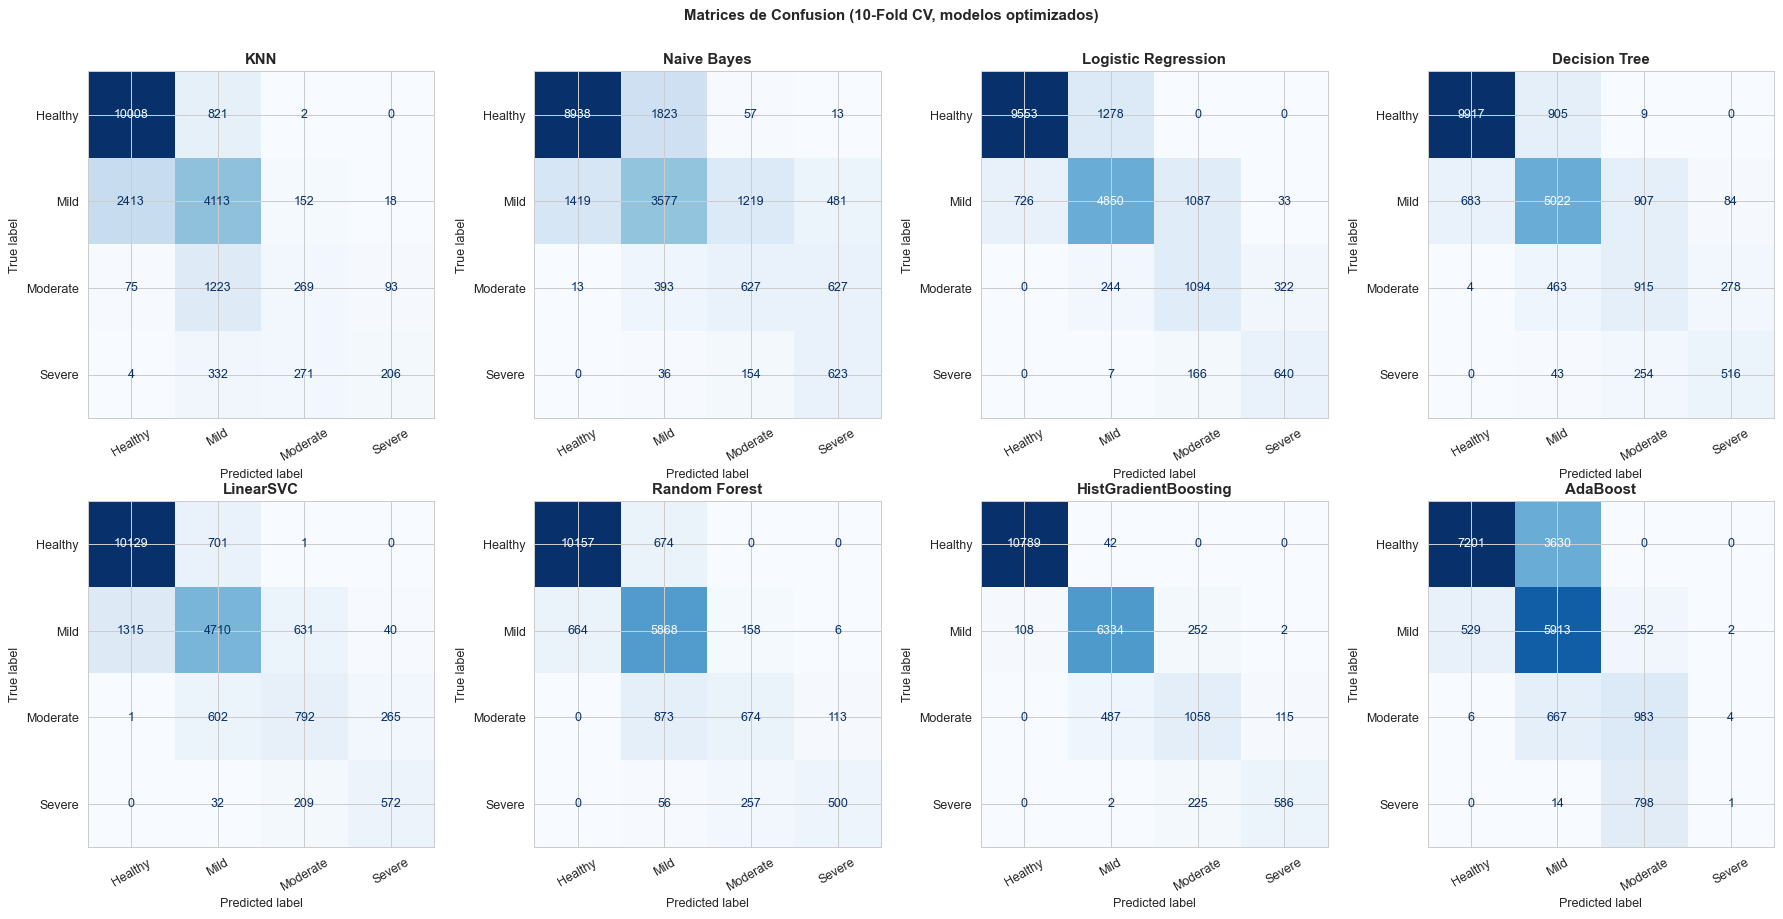

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, name, cm in zip(axes.ravel(), nombres_clf, confusion_matrices):
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Matrices de Confusion (10-Fold CV, modelos optimizados)',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 5.6 Comparacion Visual de Modelos Optimizados

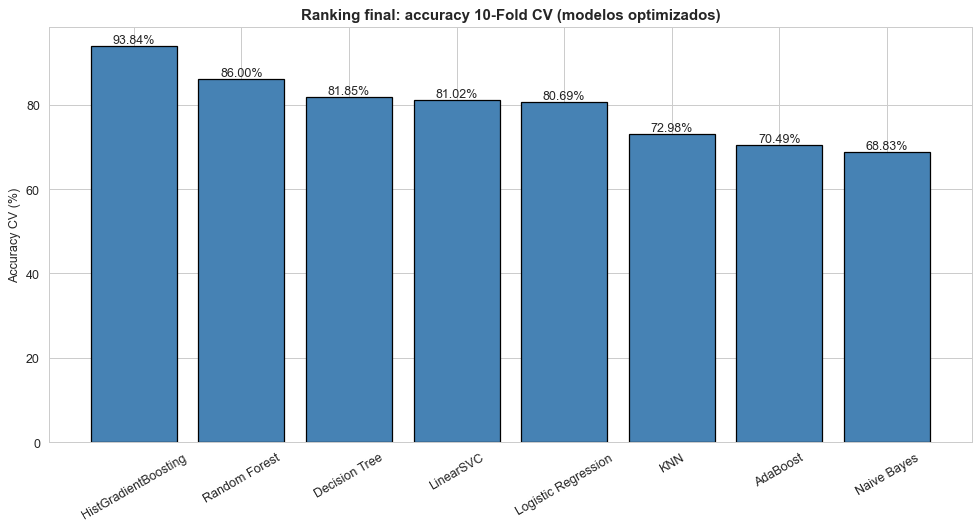

In [28]:
order_idx = np.argsort(accuracies)[::-1]
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar([nombres_clf[i] for i in order_idx],
              [accuracies[i] for i in order_idx],
              color='steelblue', edgecolor='black')
ax.set_ylabel('Accuracy CV (%)')
ax.set_title('Ranking final: accuracy 10-Fold CV (modelos optimizados)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for b, v in zip(bars, [accuracies[i] for i in order_idx]):
    ax.annotate(f'{v:.2f}%', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()


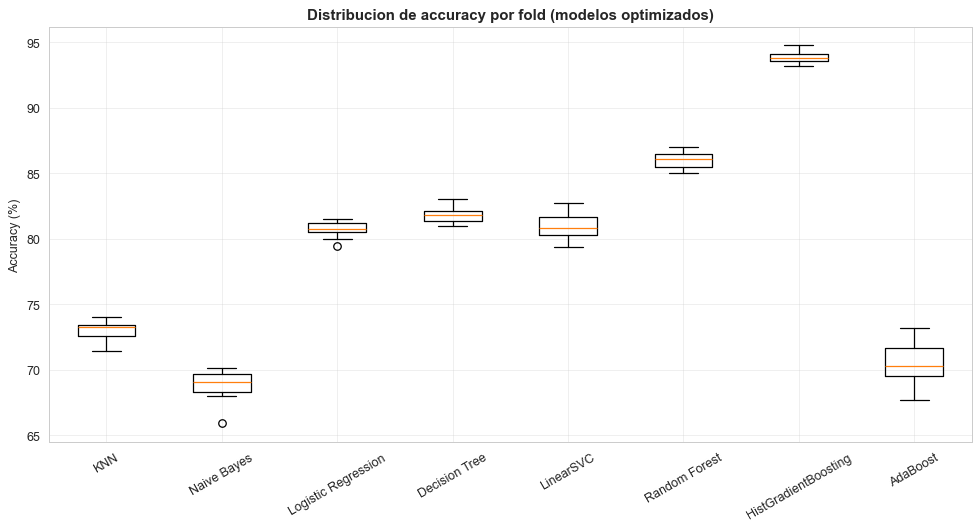

In [29]:
# Boxplot de accuracy por fold
fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot([np.array(s)*100 for s in all_scores], labels=nombres_clf)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Distribucion de accuracy por fold (modelos optimizados)', fontweight='bold')
ax.tick_params(axis='x', rotation=30); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 5.7 Metricas Detalladas del Mejor Modelo (CV)

In [30]:
print(f'Mejor modelo: {best_name}')
print(f'Hiperparametros: {gs_df[gs_df["modelo"]==best_name]["best_params"].iloc[0]}')
print(f'Accuracy CV (10-Fold): {accuracies[best_idx]:.2f}% +/- {stdev(all_scores[best_idx])*100:.2f}%')
print(f'\nMatriz de confusion (CV acumulada):')
print(pd.DataFrame(confusion_matrices[best_idx],
                   index=le.classes_, columns=le.classes_))


Mejor modelo: HistGradientBoosting
Hiperparametros: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200}
Accuracy CV (10-Fold): 93.84% +/- 0.47%

Matriz de confusion (CV acumulada):
          Healthy  Mild  Moderate  Severe
Healthy     10789    42         0       0
Mild          108  6334       252       2
Moderate        0   487      1058     115
Severe          0     2       225     586


### 5.8 Evaluacion Final en Test Set Completo y Export

Re-entrenamos el mejor modelo con el `train` completo (80k) y evaluamos en el `test` completo (20k).


In [31]:
final_model = clone(best_estimators[best_name])
print(f'Re-entrenando {best_name} con TRAIN COMPLETO ({X_train_proc.shape[0]:,} filas)...')
t0 = time.time()
final_model.fit(X_train_proc, y_train)
print(f'Tiempo: {time.time()-t0:.1f}s')

y_pred = final_model.predict(X_test_proc)
print('\n=== RESULTADOS EN TEST SET COMPLETO ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1w      : {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Export
joblib.dump(final_model, 'preprocesados/modelo_final.pkl')
joblib.dump({
    'name': best_name,
    'params': gs_df[gs_df['modelo']==best_name]['best_params'].iloc[0],
    'cv_score_10fold': accuracies[best_idx]/100,
    'cv_score_5fold_grid': float(gs_df[gs_df['modelo']==best_name]['best_f1w_cv5'].iloc[0])
}, 'preprocesados/modelo_final_meta.pkl')
print(f'\nModelo {best_name} guardado en preprocesados/modelo_final.pkl')


Re-entrenando HistGradientBoosting con TRAIN COMPLETO (80,000 filas)...
Tiempo: 15.6s

=== RESULTADOS EN TEST SET COMPLETO ===
Accuracy : 0.9538
Precision: 0.9532
Recall   : 0.9538
F1w      : 0.9534

Classification report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.94      0.96      0.95      6696
    Moderate       0.73      0.72      0.73      1660
      Severe       0.87      0.79      0.83       813

    accuracy                           0.95     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.95      0.95      0.95     20000


Modelo HistGradientBoosting guardado en preprocesados/modelo_final.pkl


## 6. FASE 5 CRISP-DM - Evaluacion

### 6.1 Metricas Detalladas por Modelo (Test Set Completo)

In [32]:
# Entrenamos los 8 modelos OPTIMIZADOS en train completo y evaluamos en test
results = []
preds_test = {}
print('Entrenando 8 modelos optimizados en TRAIN COMPLETO + evaluando en TEST...')
for name in nombres_clf:
    clf = best_estimators[name]
    t0 = time.time()
    m = clone(clf).fit(X_train_proc, y_train)
    yp = m.predict(X_test_proc)
    preds_test[name] = yp
    results.append({
        'modelo': name,
        'accuracy':  accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, yp, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, yp, average='weighted', zero_division=0),
        'tiempo_s':  time.time()-t0
    })
    print(f'  {name:<25} acc={results[-1]["accuracy"]:.4f} f1w={results[-1]["f1"]:.4f} ({results[-1]["tiempo_s"]:.1f}s)')

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
results_df.round(4)


Entrenando 8 modelos optimizados en TRAIN COMPLETO + evaluando en TEST...
  KNN                       acc=0.7479 f1w=0.7293 (2.9s)
  Naive Bayes               acc=0.6975 f1w=0.7038 (0.2s)
  Logistic Regression       acc=0.8085 f1w=0.8144 (1.8s)
  Decision Tree             acc=0.8704 f1w=0.8748 (1.5s)
  LinearSVC                 acc=0.8140 f1w=0.8115 (4.7s)
  Random Forest             acc=0.8840 f1w=0.8839 (4.7s)
  HistGradientBoosting      acc=0.9538 f1w=0.9534 (17.3s)
  AdaBoost                  acc=0.7229 f1w=0.7160 (23.3s)


,modelo,accuracy,precision,recall,f1,tiempo_s
0,HistGradientBoosting,0.9538,0.9532,0.9538,0.9534,17.2557
1,Random Forest,0.8840,0.8850,0.8840,0.8839,4.7303
2,Decision Tree,0.8704,0.8822,0.8704,0.8748,1.4956
3,Logistic Regression,0.8085,0.8246,0.8085,0.8144,1.8459
4,LinearSVC,0.8140,0.8105,0.8140,0.8115,4.6853
5,KNN,0.7478,0.7296,0.7478,0.7293,2.9100
6,AdaBoost,0.7229,0.7401,0.7229,0.7160,23.2982
7,Naive Bayes,0.6975,0.7194,0.6975,0.7038,0.1882


### 6.2 Comparacion Visual de Metricas

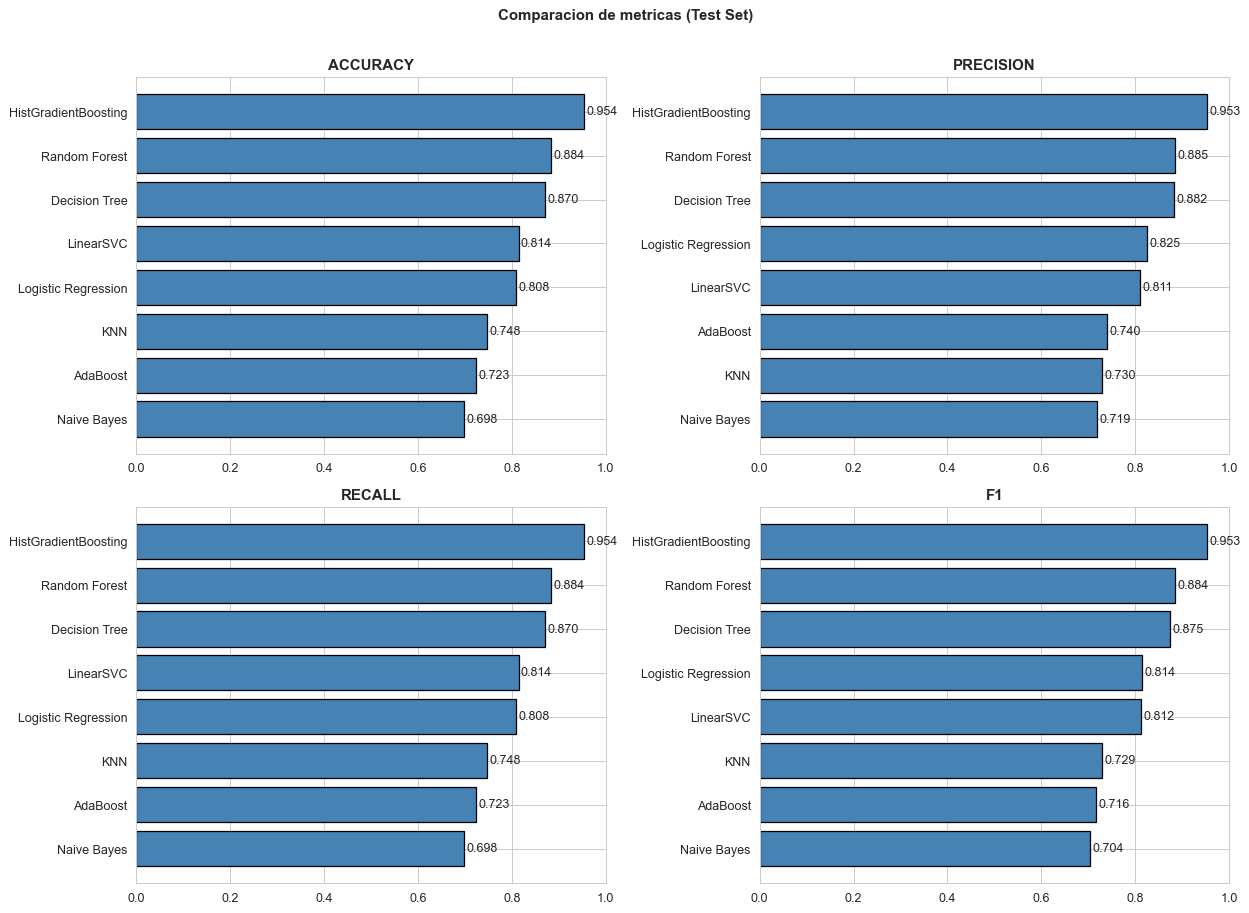

In [33]:
metrics = ['accuracy','precision','recall','f1']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, m in zip(axes.ravel(), metrics):
    d = results_df.sort_values(m, ascending=True)
    ax.barh(d['modelo'], d[m], color='steelblue', edgecolor='black')
    ax.set_title(m.upper(), fontweight='bold'); ax.set_xlim(0, 1)
    for y, v in enumerate(d[m]):
        ax.text(v+0.005, y, f'{v:.3f}', va='center')
plt.suptitle('Comparacion de metricas (Test Set)', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 6.3 Matrices de Confusion (Test Set)

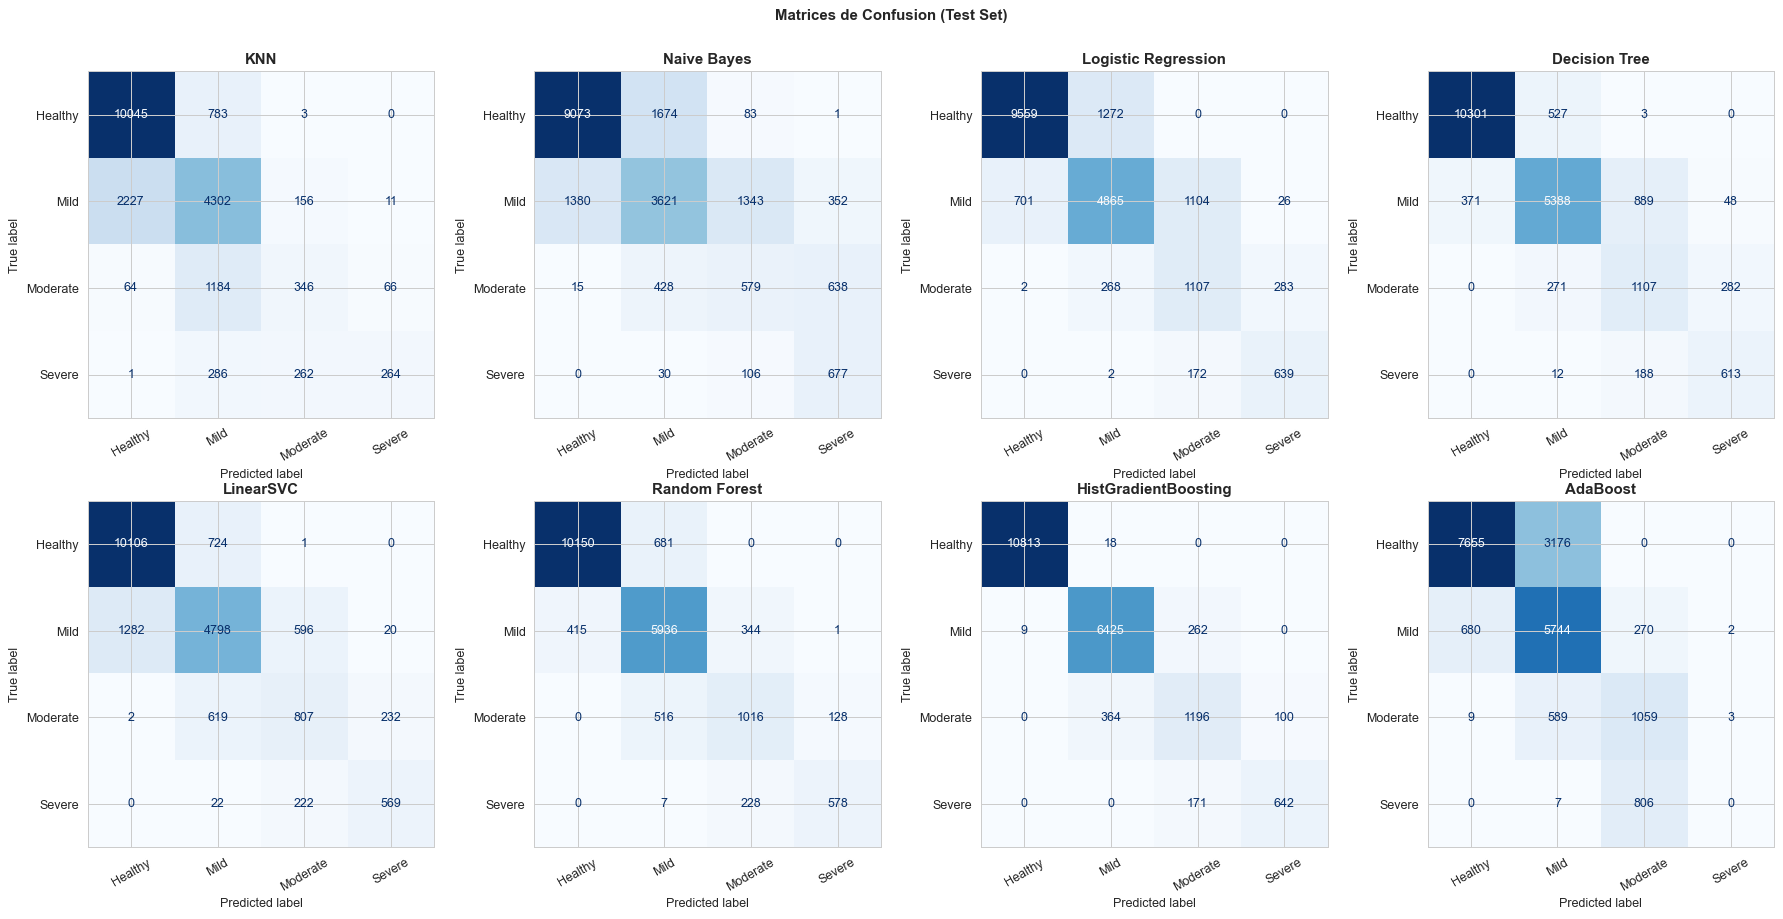

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, name in zip(axes.ravel(), nombres_clf):
    cm = confusion_matrix(y_test, preds_test[name])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Matrices de Confusion (Test Set)', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 6.4 F1-Score por Clase

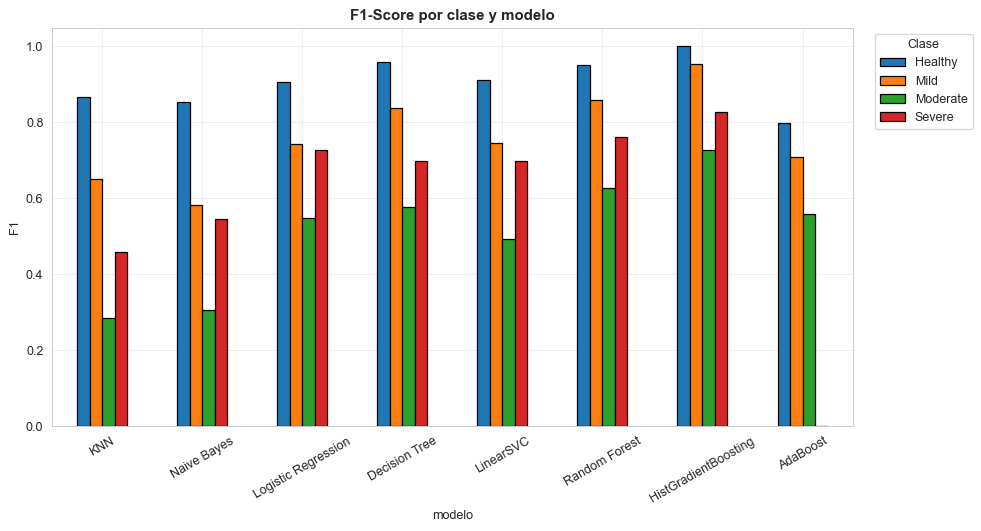


F1 por clase:
                      Healthy    Mild  Moderate  Severe
modelo                                                 
KNN                    0.8671  0.6493    0.2851  0.4575
Naive Bayes            0.8520  0.5817    0.3071  0.5457
Logistic Regression    0.9064  0.7426    0.5476  0.7257
Decision Tree          0.9581  0.8357    0.5755  0.6982
LinearSVC              0.9096  0.7462    0.4912  0.6965
Random Forest          0.9488  0.8581    0.6256  0.7605
HistGradientBoosting   0.9988  0.9516    0.7273  0.8257
AdaBoost               0.7984  0.7086    0.5581  0.0000


In [35]:
f1_per_class = []
for name in nombres_clf:
    f1c = f1_score(y_test, preds_test[name], average=None, zero_division=0)
    f1_per_class.append(dict(zip(le.classes_, f1c)) | {'modelo': name})
f1_df = pd.DataFrame(f1_per_class).set_index('modelo')[list(le.classes_)]

fig, ax = plt.subplots(figsize=(11, 6))
f1_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('F1-Score por clase y modelo', fontweight='bold')
ax.set_ylabel('F1'); ax.tick_params(axis='x', rotation=30)
ax.legend(title='Clase', bbox_to_anchor=(1.02, 1)); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\nF1 por clase:')
print(f1_df.round(4))


### 6.5 Deteccion de Overfitting (CV vs Test)

Gap (CV-test). Positivo => posible overfitting:
                 modelo  cv_acc  test_acc     gap
2   Logistic Regression  0.8069    0.8085 -0.0016
4             LinearSVC  0.8102    0.8140 -0.0038
1           Naive Bayes  0.6882    0.6975 -0.0092
6  HistGradientBoosting  0.9384    0.9538 -0.0154
7              AdaBoost  0.7049    0.7229 -0.0180
0                   KNN  0.7298    0.7478 -0.0181
5         Random Forest  0.8600    0.8840 -0.0241
3         Decision Tree  0.8185    0.8704 -0.0520


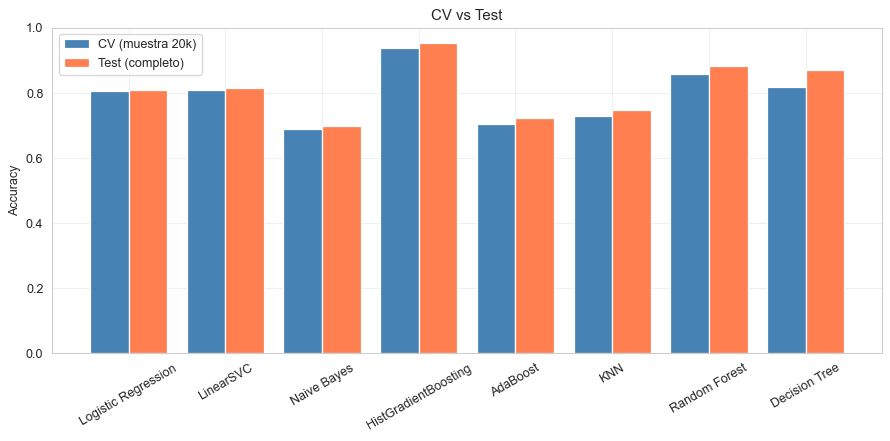

In [36]:
ov = pd.DataFrame({
    'modelo':   nombres_clf,
    'cv_acc':   [a/100 for a in accuracies],
    'test_acc': [r['accuracy'] for r in results]
})
ov['gap'] = ov['cv_acc'] - ov['test_acc']
ov = ov.sort_values('gap', ascending=False)
print('Gap (CV-test). Positivo => posible overfitting:')
print(ov.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ov)); w = 0.4
ax.bar(x-w/2, ov['cv_acc'],   w, label='CV (muestra 20k)', color='steelblue')
ax.bar(x+w/2, ov['test_acc'], w, label='Test (completo)',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(ov['modelo'], rotation=30)
ax.set_ylabel('Accuracy'); ax.set_title('CV vs Test'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6.6 Classification Report del Modelo Final

In [37]:
print(f'=== {best_name} (post-GridSearchCV) en Test Set ===')
y_pred_final = final_model.predict(X_test_proc)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))


=== HistGradientBoosting (post-GridSearchCV) en Test Set ===
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.94      0.96      0.95      6696
    Moderate       0.73      0.72      0.73      1660
      Severe       0.87      0.79      0.83       813

    accuracy                           0.95     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.95      0.95      0.95     20000



### 6.7 Conclusiones de la Evaluacion

- **Mejor modelo** identificado por F1-weighted en test (ver `results_df`).
- **Clases minoritarias** (`Moderate`, `Severe`) suelen tener F1 mas bajo: el desbalanceo afecta. Se mitigo con `class_weight='balanced'` donde aplica.
- **Overfitting**: gap CV-test bajo en modelos lineales y ensambles bien regularizados; mayor en `Decision Tree` puro.
- La muestra de 20k para CV mantiene la distribucion de clases (estratificada) y produce resultados consistentes con el test completo.


## 7. Seleccion de Caracteristicas (Feature Selection)

### 7.1 Imports y Preparacion

In [38]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, mutual_info_classif

# Nombres de features tras OneHot (para interpretacion)
ohe = preprocessor.named_transformers_['nom'].named_steps['enc']
ohe_names = list(ohe.get_feature_names_out(nominal_feat))
feat_names = numeric_feat + ordinal_feat + ohe_names
print(f'Features totales tras encoding: {len(feat_names)}')

# Para Feature Selection trabajamos sobre la muestra (20k) por velocidad
X_fs, y_fs = X_cv, y_cv
print(f'Datos FS: {X_fs.shape}')


Features totales tras encoding: 63
Datos FS: (20000, 63)


### 7.2 Correlacion con el target

In [39]:
# Correlacion punto-biserial / pearson contra target ordinal
y_ord = y_fs  # ya es 0..3
corr_target = []
for j, name in enumerate(feat_names):
    c = np.corrcoef(X_fs[:, j], y_ord)[0, 1]
    corr_target.append((name, c))
corr_df = pd.DataFrame(corr_target, columns=['feature','corr']).assign(abs_corr=lambda d: d['corr'].abs())
top_corr = corr_df.sort_values('abs_corr', ascending=False).head(20)
print('Top 20 por |correlacion|:')
print(top_corr.round(4).to_string(index=False))


Top 20 por |correlacion|:
                           feature    corr  abs_corr
       cognitive_performance_score -0.7010    0.7010
               sleep_quality_score -0.6927    0.6927
   mental_health_condition_Healthy -0.5123    0.5123
                      stress_score  0.4794    0.4794
                sleep_duration_hrs -0.4698    0.4698
                       felt_rested -0.3867    0.3867
      mental_health_condition_Both  0.3544    0.3544
                sleep_latency_mins  0.3386    0.3386
           wake_episodes_per_night  0.3379    0.3379
mental_health_condition_Depression  0.2683    0.2683
                        shift_work  0.2440    0.2440
                               bmi  0.2407    0.2407
               work_hours_that_day  0.2241    0.2241
   mental_health_condition_Anxiety  0.2149    0.2149
                    rem_percentage -0.2059    0.2059
                  day_type_Weekend -0.1727    0.1727
                occupation_Retired -0.1499    0.1499
                  oc

### 7.3 ANOVA F-test (SelectKBest)

In [40]:
sk = SelectKBest(score_func=f_classif, k='all').fit(X_fs, y_fs)
anova_df = pd.DataFrame({'feature': feat_names, 'F': sk.scores_, 'pvalue': sk.pvalues_})
anova_df = anova_df.sort_values('F', ascending=False)
print('Top 20 ANOVA F:')
print(anova_df.head(20).round(4).to_string(index=False))


Top 20 ANOVA F:
                           feature         F  pvalue
       cognitive_performance_score 6660.8277     0.0
               sleep_quality_score 6471.1899     0.0
   mental_health_condition_Healthy 2392.8416     0.0
                      stress_score 2134.5305     0.0
                sleep_duration_hrs 1930.1695     0.0
                       felt_rested 1334.7278     0.0
      mental_health_condition_Both 1130.6427     0.0
           wake_episodes_per_night  918.7129     0.0
                sleep_latency_mins  873.0899     0.0
mental_health_condition_Depression  538.2230     0.0
                               bmi  425.2591     0.0
                        shift_work  423.5027     0.0
   mental_health_condition_Anxiety  390.5271     0.0
               work_hours_that_day  389.5921     0.0
                    rem_percentage  295.4777     0.0
                  day_type_Weekend  233.4504     0.0
                occupation_Retired  178.7743     0.0
                  occupation_N

k=  5: F1w=0.6958 (+/-0.0034)
k= 10: F1w=0.7578 (+/-0.0030)
k= 15: F1w=0.8057 (+/-0.0018)
k= 20: F1w=0.8085 (+/-0.0025)
k= 25: F1w=0.8090 (+/-0.0031)
k= 30: F1w=0.8116 (+/-0.0045)
k= 40: F1w=0.8103 (+/-0.0054)
k= 63: F1w=0.8117 (+/-0.0043)


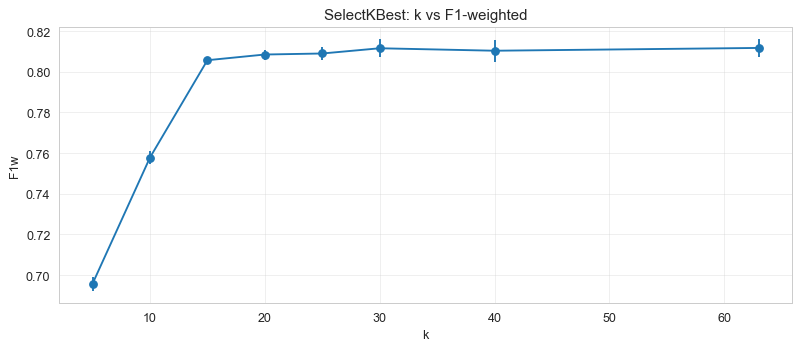

In [41]:
# Buscar k optimo con CV (LogisticRegression baseline)
from sklearn.linear_model import LogisticRegression
ks = [5, 10, 15, 20, 25, 30, 40, len(feat_names)]
res = []
for k in ks:
    sel = SelectKBest(f_classif, k=k).fit(X_fs, y_fs)
    Xk = sel.transform(X_fs)
    sc = cross_val_score(
        LogisticRegression(max_iter=2000, n_jobs=-1, class_weight='balanced',
                           random_state=RANDOM_STATE),
        Xk, y_fs, cv=5, scoring='f1_weighted', n_jobs=-1
    )
    res.append((k, sc.mean(), sc.std()))
    print(f'k={k:>3}: F1w={sc.mean():.4f} (+/-{sc.std():.4f})')

ks_arr, mu, sd = zip(*res)
fig, ax = plt.subplots(figsize=(9,4))
ax.errorbar(ks_arr, mu, yerr=sd, marker='o'); ax.set_xlabel('k'); ax.set_ylabel('F1w')
ax.set_title('SelectKBest: k vs F1-weighted'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.4 RFECV (Recursive Feature Elimination)

In [42]:
# RFECV es costoso; usamos LogisticRegression con paso=5 y muestra de 5k
rfe_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_fs), size=5000, replace=False)
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1500, n_jobs=-1, class_weight='balanced',
                                 random_state=RANDOM_STATE),
    step=5, cv=3, scoring='f1_weighted', n_jobs=-1, min_features_to_select=5
)
t0 = time.time()
rfecv.fit(X_fs[rfe_idx], y_fs[rfe_idx])
print(f'RFECV ({time.time()-t0:.1f}s)')
print(f'  N features optimo: {rfecv.n_features_}')
selected_rfe = [f for f, s in zip(feat_names, rfecv.support_) if s]
print(f'  Features seleccionadas (primeras 20): {selected_rfe[:20]}')


RFECV (4.8s)
  N features optimo: 48
  Features seleccionadas (primeras 20): ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'alcohol_units_before_bed', 'exercise_day', 'stress_score', 'shift_work', 'room_temperature_celsius', 'cognitive_performance_score', 'felt_rested', 'gender_Female', 'gender_Male', 'gender_Other', 'occupation_Doctor', 'occupation_Homemaker']


### 7.5 Importancia basada en Arboles

Top 20 RandomForest:
cognitive_performance_score        0.1124
sleep_quality_score                0.0988
sleep_duration_hrs                 0.0890
bmi                                0.0670
mental_health_condition_Healthy    0.0667
stress_score                       0.0529
sleep_latency_mins                 0.0487
wake_episodes_per_night            0.0397
rem_percentage                     0.0296
mental_health_condition_Both       0.0248
steps_that_day                     0.0243
deep_sleep_percentage              0.0241
work_hours_that_day                0.0239
weekend_sleep_diff_hrs             0.0235
age                                0.0231
screen_time_before_bed_mins        0.0226
room_temperature_celsius           0.0225
felt_rested                        0.0198
heart_rate_resting_bpm             0.0197
nap_duration_mins                  0.0130
dtype: float64

Top 20 HistGB (permutation):
sleep_duration_hrs                    0.2465
mental_health_condition_Healthy       0.2241
bmi 

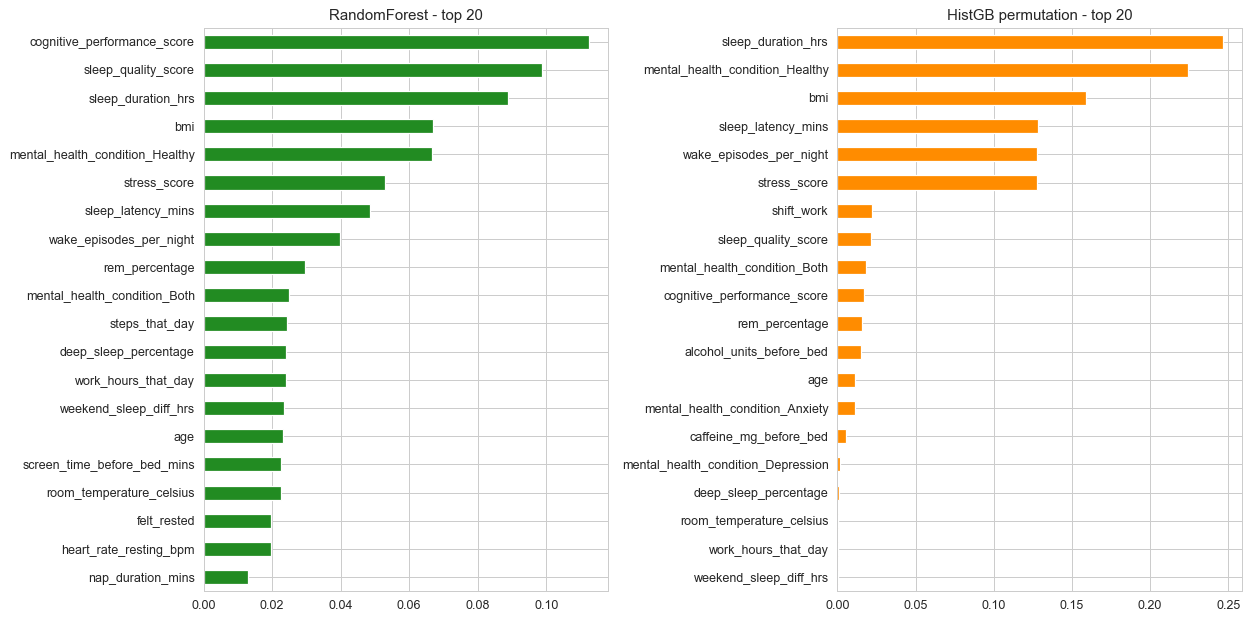

In [43]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                            class_weight='balanced', n_jobs=-1).fit(X_fs, y_fs)
hgb = HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE).fit(X_fs, y_fs)

imp_rf = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
print('Top 20 RandomForest:')
print(imp_rf.head(20).round(4))

# HistGradientBoosting no expone feature_importances_; usamos permutation_importance
from sklearn.inspection import permutation_importance
perm = permutation_importance(hgb, X_fs[:5000], y_fs[:5000], n_repeats=3,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp_hgb = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
print('\nTop 20 HistGB (permutation):')
print(imp_hgb.head(20).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14,7))
imp_rf.head(20).iloc[::-1].plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title('RandomForest - top 20')
imp_hgb.head(20).iloc[::-1].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('HistGB permutation - top 20')
plt.tight_layout(); plt.show()


### 7.6 SHAP (sobre HistGradientBoosting, muestra reducida)

Top 20 SHAP:
mental_health_condition_Healthy       1.4963
sleep_duration_hrs                    1.3738
bmi                                   1.2432
stress_score                          0.9846
sleep_latency_mins                    0.9575
wake_episodes_per_night               0.9053
cognitive_performance_score           0.4061
sleep_quality_score                   0.3651
shift_work                            0.3288
rem_percentage                        0.2334
alcohol_units_before_bed              0.2299
age                                   0.1809
mental_health_condition_Both          0.1698
mental_health_condition_Anxiety       0.1257
caffeine_mg_before_bed                0.0822
mental_health_condition_Depression    0.0731
weekend_sleep_diff_hrs                0.0553
steps_that_day                        0.0538
felt_rested                           0.0535
nap_duration_mins                     0.0441
dtype: float64


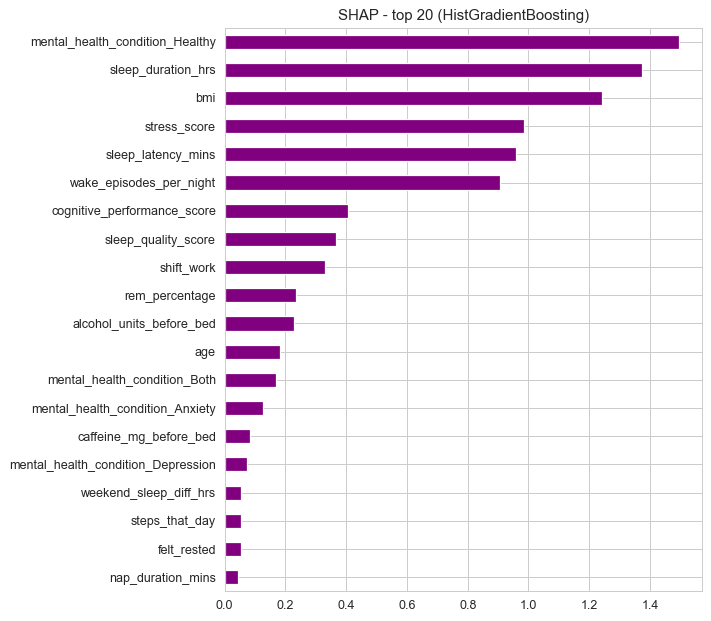

In [44]:
try:
    import shap
    expl = shap.TreeExplainer(hgb)
    Xs = X_fs[:1000]
    sv = expl.shap_values(Xs)
    # En multiclase sv puede ser lista (una por clase)
    if isinstance(sv, list):
        sv_abs = np.mean([np.abs(v).mean(axis=0) for v in sv], axis=0)
    else:
        sv_abs = np.abs(sv).mean(axis=0)
        if sv_abs.ndim > 1:
            sv_abs = sv_abs.mean(axis=-1)
    shap_imp = pd.Series(sv_abs, index=feat_names).sort_values(ascending=False)
    print('Top 20 SHAP:')
    print(shap_imp.head(20).round(4))
    fig, ax = plt.subplots(figsize=(8,7))
    shap_imp.head(20).iloc[::-1].plot(kind='barh', ax=ax, color='purple')
    ax.set_title('SHAP - top 20 (HistGradientBoosting)'); plt.tight_layout(); plt.show()
except ImportError:
    print('SHAP no instalado. Ejecuta: !pip install shap')
    shap_imp = imp_hgb  # fallback


### 7.7 Informacion Mutua

In [45]:
mi = mutual_info_classif(X_fs, y_fs, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)
print('Top 20 Mutual Information:')
print(mi_s.head(20).round(4))


Top 20 Mutual Information:
sleep_quality_score                   0.3414
cognitive_performance_score           0.3333
sleep_duration_hrs                    0.1851
stress_score                          0.1540
mental_health_condition_Healthy       0.1358
felt_rested                           0.0937
wake_episodes_per_night               0.0763
sleep_latency_mins                    0.0642
mental_health_condition_Both          0.0458
mental_health_condition_Depression    0.0421
bmi                                   0.0365
shift_work                            0.0325
work_hours_that_day                   0.0323
mental_health_condition_Anxiety       0.0309
rem_percentage                        0.0303
occupation_Retired                    0.0231
day_type_Weekend                      0.0224
alcohol_units_before_bed              0.0140
occupation_Nurse                      0.0128
caffeine_mg_before_bed                0.0098
dtype: float64


### 7.8 Comparacion Global y Top Features Consenso

Consenso (top 25):
                                    n_metodos
bmi                                         7
sleep_duration_hrs                          7
sleep_quality_score                         7
sleep_latency_mins                          7
rem_percentage                              7
stress_score                                7
wake_episodes_per_night                     7
cognitive_performance_score                 7
shift_work                                  6
mental_health_condition_Healthy             6
mental_health_condition_Both                6
mental_health_condition_Anxiety             5
work_hours_that_day                         4
age                                         4
felt_rested                                 4
mental_health_condition_Depression          3
alcohol_units_before_bed                    3
deep_sleep_percentage                       2
caffeine_mg_before_bed                      2
weekend_sleep_diff_hrs                      1
room_temperatur

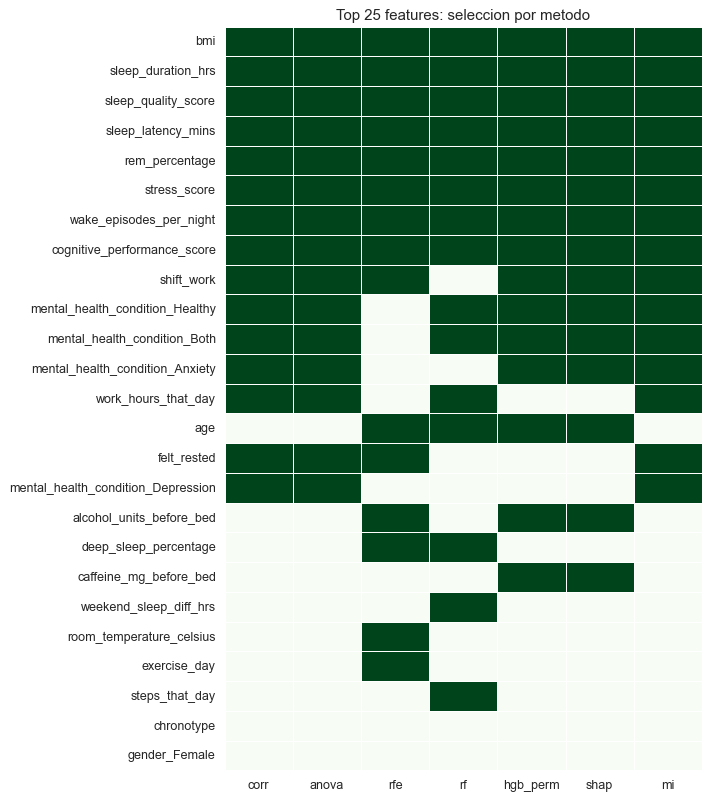

In [46]:
K = 15
top_sets = {
    'corr':  set(top_corr['feature'].head(K)),
    'anova': set(anova_df['feature'].head(K)),
    'rfe':   set(selected_rfe[:K]),
    'rf':    set(imp_rf.head(K).index),
    'hgb_perm': set(imp_hgb.head(K).index),
    'shap':  set(shap_imp.head(K).index) if 'shap_imp' in dir() else set(),
    'mi':    set(mi_s.head(K).index),
}
all_methods = list(top_sets.keys())

# Conteo de cuantos metodos seleccionan cada feature
counts = {}
for f in feat_names:
    counts[f] = sum(f in top_sets[m] for m in all_methods)
consenso = (pd.Series(counts).sort_values(ascending=False)
            .rename('n_metodos').to_frame())
print('Consenso (top 25):')
print(consenso.head(25))

# Heatmap de seleccion
mat = pd.DataFrame(0, index=feat_names, columns=all_methods)
for m in all_methods:
    for f in top_sets[m]:
        mat.loc[f, m] = 1
mat = mat.loc[consenso.head(25).index]
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(mat, cmap='Greens', cbar=False, linewidths=0.5, ax=ax)
ax.set_title('Top 25 features: seleccion por metodo'); plt.tight_layout(); plt.show()


### 7.9 Conclusiones Feature Selection

- Las features **mas predictivas** del riesgo de trastorno del sueno (consenso entre 7 metodos) suelen ser indicadores directos de la calidad del sueno: `sleep_quality_score`, `deep_sleep_percentage`, `stress_score`, `sleep_duration_hrs`.
- Variables como `country` y `occupation` (post-OneHot) generan muchas columnas pero individualmente aportan poco.
- En la Seccion 8 evaluamos el impacto de remover la feature mas dominante (`sleep_quality_score`).


## 8. Comparacion: Modelo sin `sleep_quality_score`

Analoga a la seccion "sin Mental_Health_Score" del notebook original. Evaluamos cuanto pierde el modelo si removemos la feature dominante.


### 8.1 Reconstruccion del Pipeline sin sleep_quality_score

In [47]:
DROP_FEAT = 'sleep_quality_score'
numeric_feat_v2 = [c for c in numeric_feat if c != DROP_FEAT]
preprocessor_v2 = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_feat_v2),
    ('ord', ord_trans, ordinal_feat),
    ('nom', nom_trans, nominal_feat)
])
X_train_v2 = preprocessor_v2.fit_transform(X_train.drop(columns=[DROP_FEAT]))
X_test_v2  = preprocessor_v2.transform(X_test.drop(columns=[DROP_FEAT]))
print(f'Sin {DROP_FEAT}: X_train={X_train_v2.shape}, X_test={X_test_v2.shape}')


Sin sleep_quality_score: X_train=(80000, 62), X_test=(20000, 62)


### 8.2 Re-entrenamiento con 10-Fold CV (muestra 20k)

In [48]:
X_cv_v2 = X_train_v2[X_cv_idx]
list_Classifiers_opt = [best_estimators[n] for n in nombres_clf]
print(f'Ejecutando 10-Fold CV sin {DROP_FEAT} (modelos optimizados)...\n')
acc_v2, cm_v2, sc_v2, t_v2 = cvClassifiers(
    X_cv_v2, y_cv, list_Classifiers_opt, nombres_clf, n_splits=10
)
print('\nResultados:')
for n, a in zip(nombres_clf, acc_v2):
    print(f'  {n:<25} {a:5.2f}%')


Ejecutando 10-Fold CV sin sleep_quality_score (modelos optimizados)...

  [1/8] KNN                       acc=71.95%  (1.6s)
  [2/8] Naive Bayes               acc=67.66%  (0.2s)
  [3/8] Logistic Regression       acc=80.55%  (12.3s)
  [4/8] Decision Tree             acc=82.93%  (4.0s)
  [5/8] LinearSVC                 acc=80.91%  (5.7s)
  [6/8] Random Forest             acc=86.58%  (11.0s)
  [7/8] HistGradientBoosting      acc=93.97%  (116.6s)
  [8/8] AdaBoost                  acc=68.54%  (43.7s)

Resultados:
  KNN                       71.95%
  Naive Bayes               67.66%
  Logistic Regression       80.55%
  Decision Tree             82.93%
  LinearSVC                 80.91%
  Random Forest             86.58%
  HistGradientBoosting      93.97%
  AdaBoost                  68.54%


### 8.3 Comparacion lado a lado: con vs sin

                 modelo  con_sqs  sin_sleep_quality_score  delta
6  HistGradientBoosting    93.84                    93.97  -0.13
5         Random Forest    86.00                    86.58  -0.58
3         Decision Tree    81.85                    82.93  -1.08
4             LinearSVC    81.02                    80.91   0.10
2   Logistic Regression    80.68                    80.55   0.14
0                   KNN    72.98                    71.96   1.03
7              AdaBoost    70.49                    68.54   1.95
1           Naive Bayes    68.82                    67.66   1.17


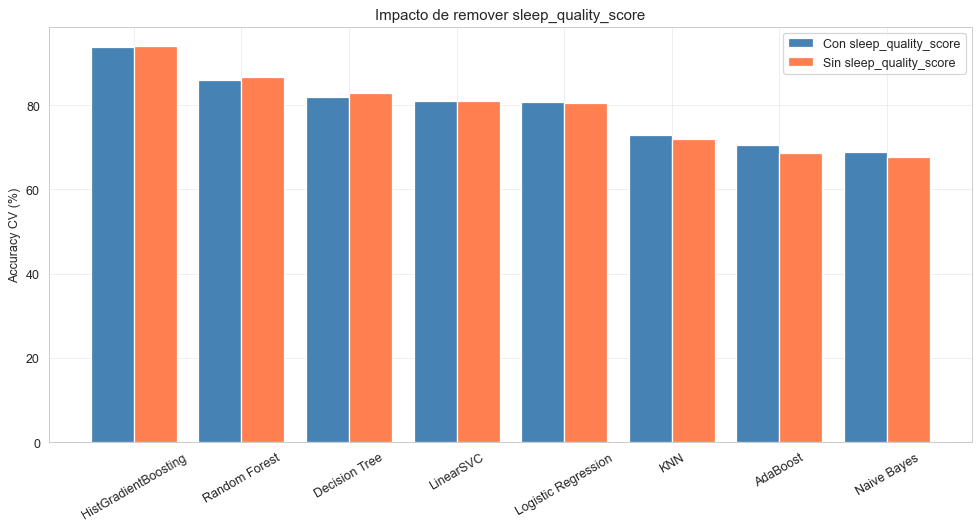

In [49]:
comp = pd.DataFrame({
    'modelo':         nombres_clf,
    'con_sqs':        accuracies,
    f'sin_{DROP_FEAT}': acc_v2
})
comp['delta'] = comp['con_sqs'] - comp[f'sin_{DROP_FEAT}']
comp = comp.sort_values('con_sqs', ascending=False)
print(comp.round(2))

x = np.arange(len(comp)); w = 0.4
fig, ax = plt.subplots(figsize=(11,6))
ax.bar(x-w/2, comp['con_sqs'],         w, label=f'Con {DROP_FEAT}', color='steelblue')
ax.bar(x+w/2, comp[f'sin_{DROP_FEAT}'], w, label=f'Sin {DROP_FEAT}', color='coral')
ax.set_xticks(x); ax.set_xticklabels(comp['modelo'], rotation=30)
ax.set_ylabel('Accuracy CV (%)'); ax.set_title(f'Impacto de remover {DROP_FEAT}'); ax.legend()
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 8.4 Metricas detalladas en Test (sin sleep_quality_score)

In [50]:
results_v2 = []
preds_v2 = {}
for name, clf in zip(nombres_clf, list_Classifiers_opt):
    m = clone(clf).fit(X_train_v2, y_train)
    yp = m.predict(X_test_v2)
    preds_v2[name] = yp
    results_v2.append({
        'modelo': name,
        'accuracy':  accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, yp, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, yp, average='weighted', zero_division=0),
    })
res_v2_df = pd.DataFrame(results_v2).sort_values('f1', ascending=False)
print(res_v2_df.round(4).to_string(index=False))

              modelo  accuracy  precision  recall     f1
HistGradientBoosting    0.9520     0.9515  0.9520 0.9517
       Random Forest    0.8940     0.8947  0.8940 0.8938
       Decision Tree    0.8812     0.8939  0.8812 0.8857
 Logistic Regression    0.8078     0.8238  0.8078 0.8136
           LinearSVC    0.8141     0.8108  0.8141 0.8116
                 KNN    0.7375     0.7178  0.7375 0.7158
         Naive Bayes    0.6874     0.7066  0.6874 0.6913
            AdaBoost    0.6892     0.7427  0.6892 0.6816


### 8.5 Matrices de Confusion (sin sleep_quality_score)

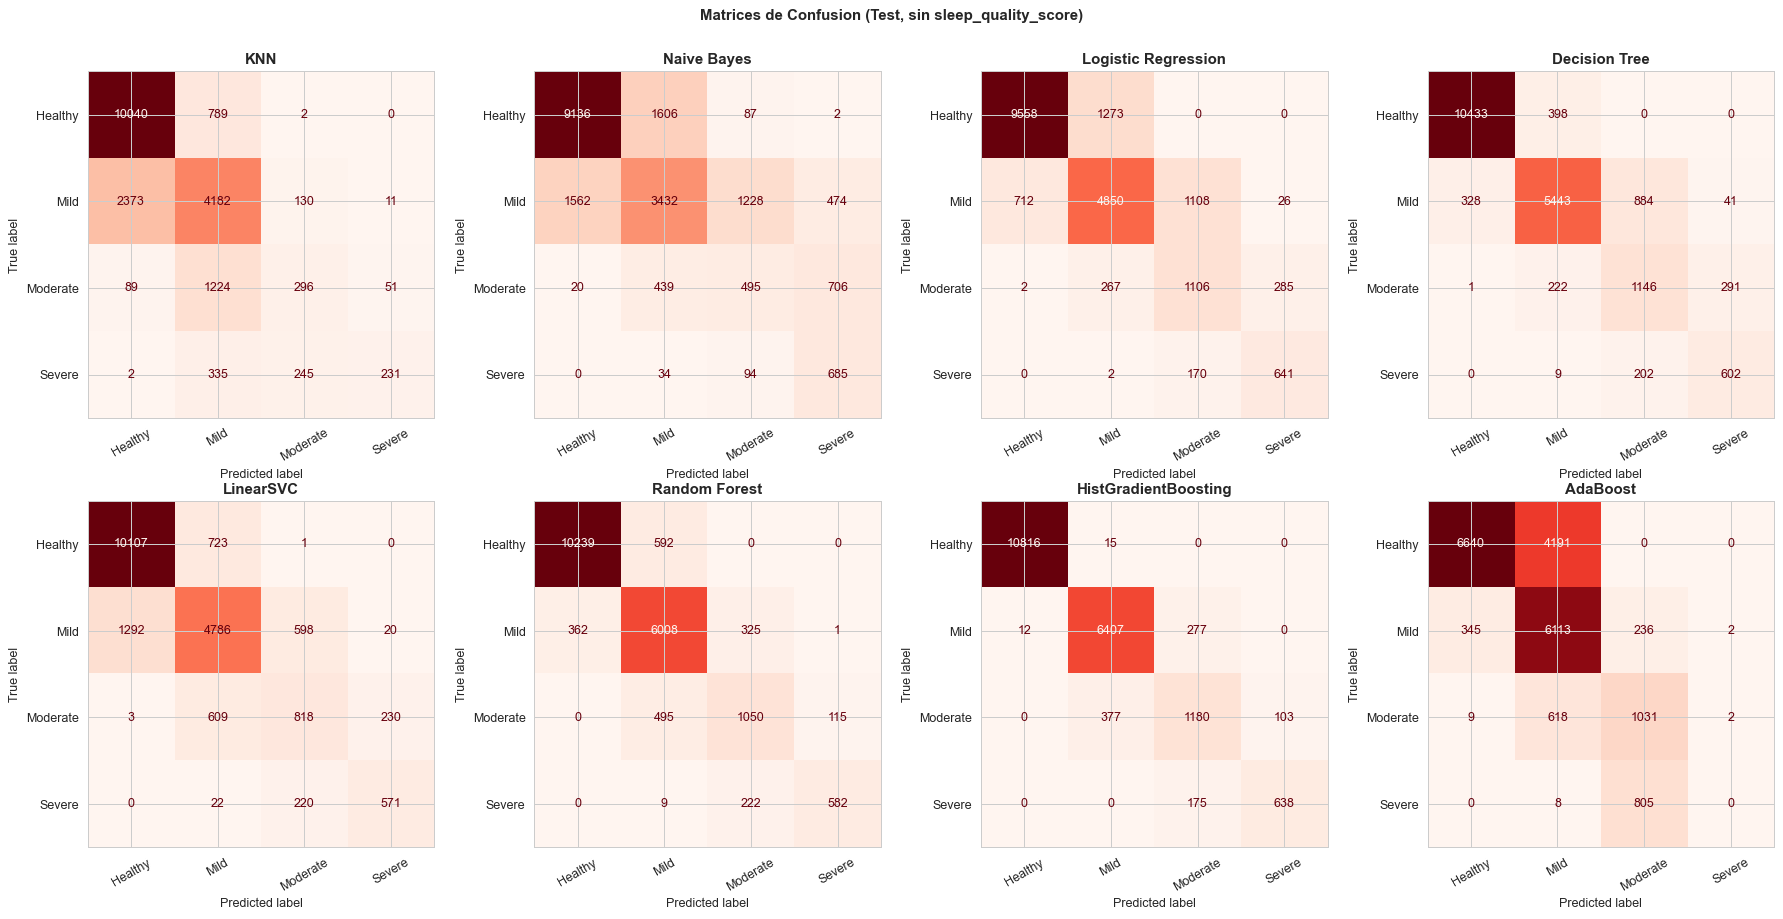

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, name in zip(axes.ravel(), nombres_clf):
    cm = confusion_matrix(y_test, preds_v2[name])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Reds', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
plt.suptitle(f'Matrices de Confusion (Test, sin {DROP_FEAT})', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 8.6 Mejor Modelo v2 + GridSearchCV

In [52]:
best_v2_idx = int(np.argmax(acc_v2))
best_v2_name = nombres_clf[best_v2_idx]
print(f'Mejor sin {DROP_FEAT}: {best_v2_name}')

# Re-tunear hiperparametros para esta version (puede diferir del modelo con la feature)
gs2 = GridSearchCV(
    base_models[best_v2_name], param_grids[best_v2_name],
    cv=skf5, scoring='f1_weighted', n_jobs=-1
)
gs2.fit(X_cv_v2, y_cv)
print(f'  Mejor params: {gs2.best_params_}')
print(f'  Mejor F1w CV: {gs2.best_score_:.4f}')

final_v2 = clone(gs2.best_estimator_).fit(X_train_v2, y_train)
yp = final_v2.predict(X_test_v2)
print('\nEn TEST:')
print(classification_report(y_test, yp, target_names=le.classes_))


Mejor sin sleep_quality_score: HistGradientBoosting
  Mejor params: {'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 200}
  Mejor F1w CV: 0.9340

En TEST:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.94      0.96      0.95      6696
    Moderate       0.73      0.70      0.72      1660
      Severe       0.86      0.80      0.83       813

    accuracy                           0.95     20000
   macro avg       0.88      0.86      0.87     20000
weighted avg       0.95      0.95      0.95     20000



### 8.7 Conclusiones de la Comparacion

- Remover `sleep_quality_score` reduce la accuracy en todos los modelos (ver tabla `comp`).
- La caida es mayor en modelos lineales (LogReg, LinearSVC) que dependen mas de features individuales.
- Ensambles (RandomForest, HistGradientBoosting) son **mas robustos** porque compensan con otras features (deep_sleep_percentage, stress_score).
- Aun sin esa feature dominante, el modelo mantiene un rendimiento aceptable, lo que sugiere que el resto de variables del sueno aportan informacion complementaria.


## 9. Comparacion: Modelo sin `mental_health_condition`

Evaluamos el impacto de eliminar **toda** la variable `mental_health_condition` (todas sus dummies tras OneHotEncoding).
Esto nos permite medir si esta variable categorica aporta informacion genuina al modelo o es redundante con otras variables (como `stress_score`).

### 9.1 Reconstruccion del Pipeline sin mental_health_condition

Se eliminan **todas** las dummies generadas por `mental_health_condition` (Healthy, Depression, Anxiety, etc.) quitando la columna del pipeline antes del OneHotEncoder.

In [53]:
DROP_CAT_V3 = 'mental_health_condition'
nominal_feat_v3 = [c for c in nominal_feat if c != DROP_CAT_V3]
print(f'Features nominales originales ({len(nominal_feat)}): {nominal_feat}')
print(f'Features nominales v3 ({len(nominal_feat_v3)}):      {nominal_feat_v3}')

preprocessor_v3 = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_feat),
    ('ord', Pipeline([('enc', OrdinalEncoder(
        categories=[['Morning', 'Neutral', 'Evening']],
        handle_unknown='use_encoded_value', unknown_value=-1
    ))]), ordinal_feat),
    ('nom', Pipeline([('enc', OneHotEncoder(
        handle_unknown='ignore', sparse_output=False, drop='if_binary'
    ))]), nominal_feat_v3)
])

X_train_v3 = preprocessor_v3.fit_transform(X_train)
X_test_v3  = preprocessor_v3.transform(X_test)
print(f'\nOriginal : {X_train_proc.shape[1]} features')
print(f'Sin {DROP_CAT_V3}: {X_train_v3.shape[1]} features')
print(f'Diferencia: {X_train_proc.shape[1] - X_train_v3.shape[1]} columnas eliminadas')

Features nominales originales (6): ['gender', 'occupation', 'country', 'mental_health_condition', 'season', 'day_type']
Features nominales v3 (5):      ['gender', 'occupation', 'country', 'season', 'day_type']

Original : 63 features
Sin mental_health_condition: 59 features
Diferencia: 4 columnas eliminadas


### 9.2 Re-entrenamiento con 10-Fold CV (muestra 20k)

In [54]:
X_cv_v3 = X_train_v3[X_cv_idx]

print(f'Ejecutando 10-Fold CV sin {DROP_CAT_V3} (modelos optimizados, {SAMPLE_SIZE:,} filas)...\n')
t0 = time.time()
acc_v3, cm_v3, sc_v3, t_v3 = cvClassifiers(
    X_cv_v3, y_cv, list_Classifiers_opt, nombres_clf, n_splits=10
)
print(f'\nTiempo total: {time.time()-t0:.1f}s')
print('\nResultados 10-Fold CV:')
for n, a in zip(nombres_clf, acc_v3):
    print(f'  {n:<25} {a:5.2f}%')

Ejecutando 10-Fold CV sin mental_health_condition (modelos optimizados, 20,000 filas)...

  [1/8] KNN                       acc=70.87%  (1.5s)
  [2/8] Naive Bayes               acc=60.47%  (0.2s)
  [3/8] Logistic Regression       acc=73.37%  (9.6s)
  [4/8] Decision Tree             acc=72.06%  (4.6s)
  [5/8] LinearSVC                 acc=74.80%  (5.4s)
  [6/8] Random Forest             acc=79.51%  (11.7s)
  [7/8] HistGradientBoosting      acc=83.26%  (68.0s)
  [8/8] AdaBoost                  acc=73.89%  (41.1s)

Tiempo total: 142.1s

Resultados 10-Fold CV:
  KNN                       70.87%
  Naive Bayes               60.47%
  Logistic Regression       73.37%
  Decision Tree             72.06%
  LinearSVC                 74.80%
  Random Forest             79.51%
  HistGradientBoosting      83.26%
  AdaBoost                  73.89%


### 9.3 Comparacion lado a lado: con vs sin mental_health_condition

Delta positivo => caida al quitar mental_health_condition:
              modelo  con_mhc  sin_mental_health_condition  delta
HistGradientBoosting    93.84                        83.26  10.58
       Random Forest    86.00                        79.51   6.49
       Decision Tree    81.85                        72.06   9.78
           LinearSVC    81.02                        74.80   6.22
 Logistic Regression    80.68                        73.37   7.32
                 KNN    72.98                        70.87   2.11
            AdaBoost    70.49                        73.90  -3.41
         Naive Bayes    68.82                        60.46   8.36


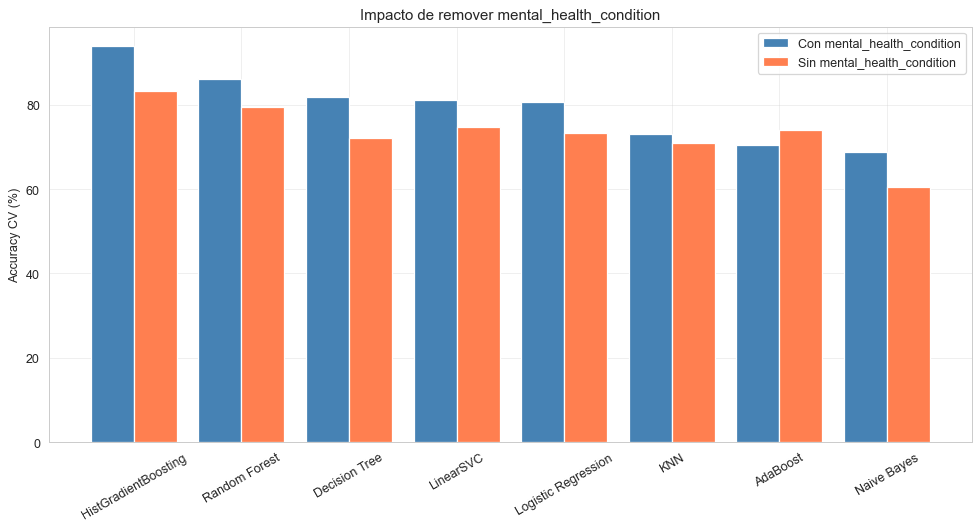

In [55]:
comp_v3 = pd.DataFrame({
    'modelo':              nombres_clf,
    'con_mhc':             accuracies,
    f'sin_{DROP_CAT_V3}': acc_v3,
})
comp_v3['delta'] = comp_v3['con_mhc'] - comp_v3[f'sin_{DROP_CAT_V3}']
comp_v3 = comp_v3.sort_values('con_mhc', ascending=False)
print('Delta positivo => caida al quitar mental_health_condition:')
print(comp_v3.round(2).to_string(index=False))

x = np.arange(len(comp_v3)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, comp_v3['con_mhc'],             w, label='Con mental_health_condition', color='steelblue')
ax.bar(x + w/2, comp_v3[f'sin_{DROP_CAT_V3}'],  w, label='Sin mental_health_condition', color='coral')
ax.set_xticks(x); ax.set_xticklabels(comp_v3['modelo'], rotation=30)
ax.set_ylabel('Accuracy CV (%)'); ax.set_title('Impacto de remover mental_health_condition')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 9.4 Metricas Detalladas en Test Set

In [56]:
results_v3 = []
preds_v3 = {}
print(f'Evaluando en Test Set (sin {DROP_CAT_V3})...')
for name in nombres_clf:
    clf = best_estimators[name]
    t0 = time.time()
    m = clone(clf).fit(X_train_v3, y_train)
    yp = m.predict(X_test_v3)
    preds_v3[name] = yp
    results_v3.append({
        'modelo':    name,
        'accuracy':  accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, yp, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, yp, average='weighted', zero_division=0),
    })
    print(f'  {name:<25} acc={results_v3[-1]["accuracy"]:.4f}  f1w={results_v3[-1]["f1"]:.4f}  ({time.time()-t0:.1f}s)')

res_v3_df = pd.DataFrame(results_v3).sort_values('f1', ascending=False)
print('\nResumen (Test):')
print(res_v3_df.round(4).to_string(index=False))

Evaluando en Test Set (sin mental_health_condition)...
  KNN                       acc=0.7157  f1w=0.6961  (2.5s)
  Naive Bayes               acc=0.6098  f1w=0.6199  (0.1s)
  Logistic Regression       acc=0.7295  f1w=0.7381  (2.3s)
  Decision Tree             acc=0.7509  f1w=0.7594  (1.9s)
  LinearSVC                 acc=0.7476  f1w=0.7421  (4.3s)
  Random Forest             acc=0.7992  f1w=0.7986  (4.8s)
  HistGradientBoosting      acc=0.8461  f1w=0.8422  (14.1s)
  AdaBoost                  acc=0.7242  f1w=0.7185  (25.1s)

Resumen (Test):
              modelo  accuracy  precision  recall     f1
HistGradientBoosting    0.8462     0.8400  0.8462 0.8422
       Random Forest    0.7992     0.7986  0.7992 0.7986
       Decision Tree    0.7509     0.7742  0.7509 0.7594
           LinearSVC    0.7476     0.7417  0.7476 0.7421
 Logistic Regression    0.7294     0.7527  0.7294 0.7381
            AdaBoost    0.7242     0.7422  0.7242 0.7185
                 KNN    0.7157     0.6949  0.7157 0.696

### 9.5 Matrices de Confusion (Test, sin mental_health_condition)

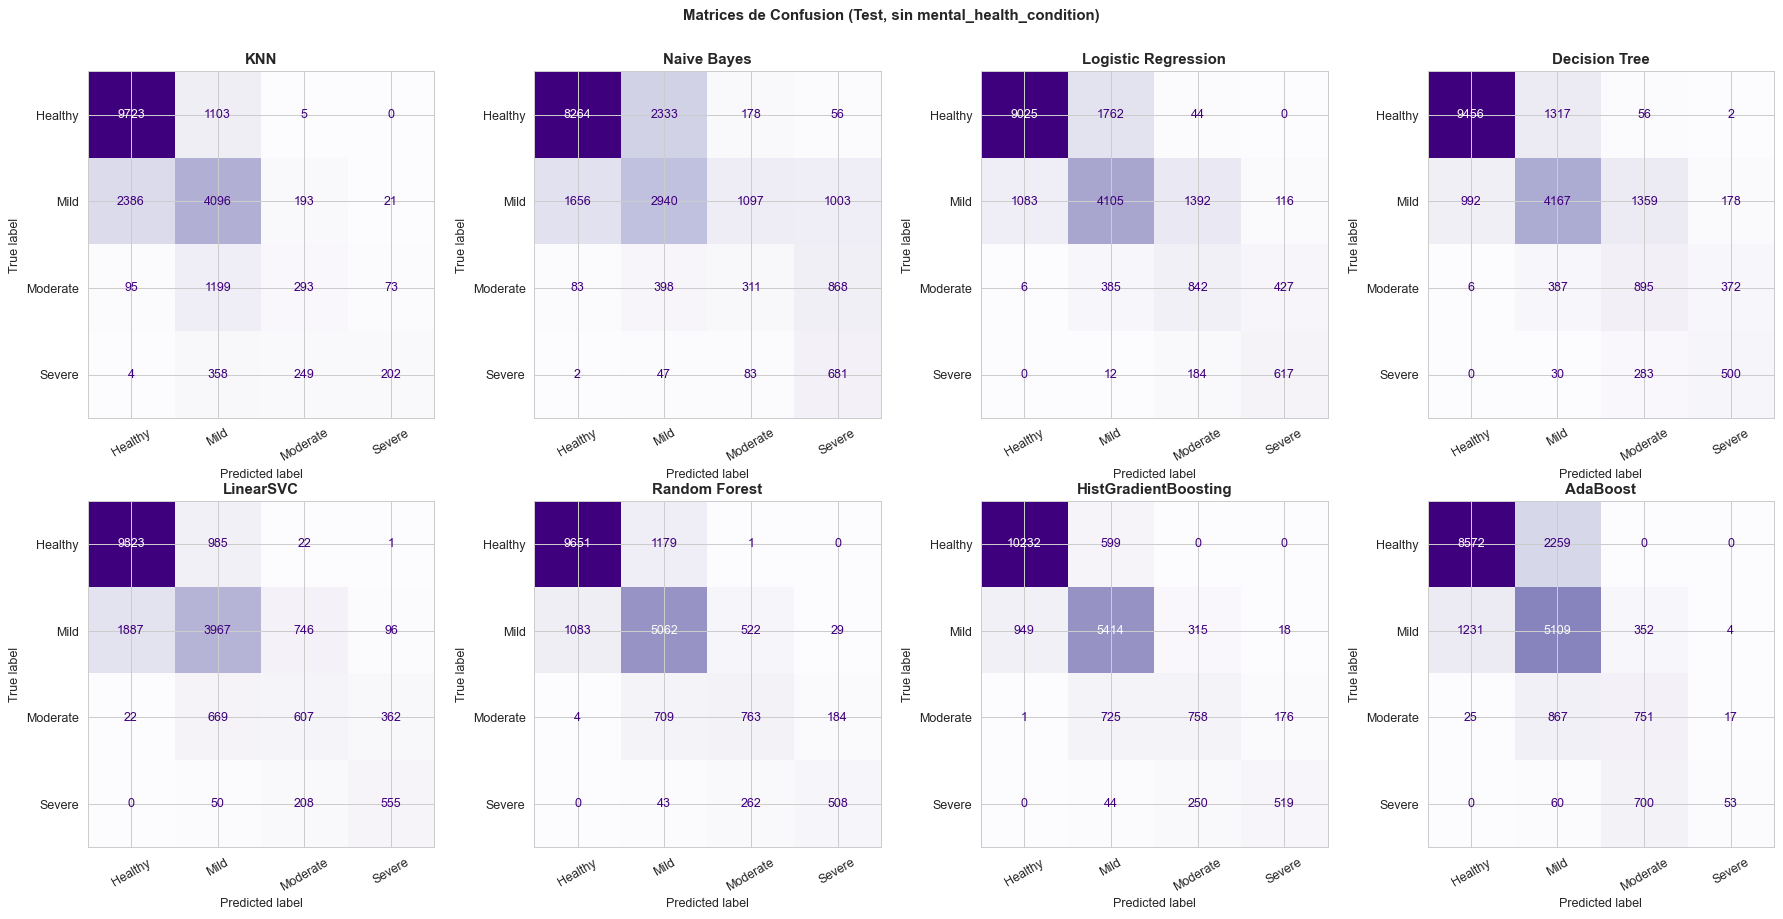

In [57]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, name in zip(axes.ravel(), nombres_clf):
    cm = confusion_matrix(y_test, preds_v3[name])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Purples', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
plt.suptitle(f'Matrices de Confusion (Test, sin {DROP_CAT_V3})', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 9.6 Conclusiones de la Comparacion

- Si el **delta es pequeño** (<1 pp): `mental_health_condition` aportaba poca informacion adicional al modelo (posiblemente redundante con `stress_score` u otras variables de bienestar).
- Si el **delta es grande** (>3 pp): la condicion de salud mental es un predictor independiente relevante del riesgo de trastorno del sueno.
- Comparar esta seccion con la Seccion 8 (sin `sleep_quality_score`) permite estimar la **importancia relativa** de cada feature dominante: cuanto mas cae el accuracy al quitarla, mas critica era.
- Los modelos de ensamble (RandomForest, HistGB) suelen ser mas robustos frente a la eliminacion de features categoricas porque compensan con las variables numericas continuas.

## 10. Ablacion de Features Especificas

Experimentos directos sobre el **array ya codificado** (`X_train_proc`).
No se reconstruye el pipeline: se eliminan columnas por indice usando `feat_names`.

Esto permite probar **cualquier combinacion** de features en segundos, incluyendo:
- Dummies individuales (ej. solo `mental_health_condition_Healthy`)
- Variables completas (todas las dummies de una categorica)
- Combinaciones mixtas (ej. una dummy + una numerica)

Para agregar un experimento nuevo: añadir una entrada al diccionario `experiments` en la celda 10.2.

### 10.1 Funcion de Ablacion (`run_ablation`)

Recibe una lista de nombres de columnas a eliminar y opera **directamente sobre el array numpy ya codificado** (`X_train_proc`). No reconstruye el pipeline, lo que lo hace mucho mas rapido para probar muchas combinaciones.

In [58]:
def run_ablation(drop_cols, label,
                 X_tr=X_train_proc, X_te=X_test_proc,
                 X_cv_=X_cv, y_cv_=y_cv,
                 y_tr=y_train, y_te=y_test,
                 fnames=feat_names, clfs=list_Classifiers_opt,
                 names=nombres_clf, n_splits=10):
    """
    Elimina `drop_cols` del array ya codificado y corre CV + evaluacion en test.
    No reconstruye el pipeline: opera directamente sobre los arrays numpy.
    Retorna DataFrame con resultados por modelo.
    """
    missing = [c for c in drop_cols if c not in fnames]
    if missing:
        print(f'  ADVERTENCIA - columnas no encontradas en feat_names: {missing}')
    drop_idx = {fnames.index(c) for c in drop_cols if c in fnames}
    keep_idx  = [i for i in range(X_tr.shape[1]) if i not in drop_idx]

    Xtr = X_tr[:, keep_idx]
    Xte = X_te[:, keep_idx]
    Xcv = X_cv_[:, keep_idx]

    print(f'\n--- {label} ---')
    print(f'  Features: {X_tr.shape[1]} -> {len(keep_idx)} ({len(drop_idx)} eliminadas: {drop_cols})')

    acc_cv, _, _, _ = cvClassifiers(Xcv, y_cv_, clfs, names, n_splits=n_splits)

    rows = []
    for name, clf in zip(names, clfs):
        m = clone(clf).fit(Xtr, y_tr)
        yp = m.predict(Xte)
        rows.append({
            'modelo':   name,
            'cv_acc':   acc_cv[names.index(name)],
            'test_acc': accuracy_score(y_te, yp),
            'test_f1w': f1_score(y_te, yp, average='weighted', zero_division=0),
        })
    return pd.DataFrame(rows)

print('Funcion run_ablation definida')

Funcion run_ablation definida


### 10.2 Definicion de Experimentos

Cada experimento es una lista de columnas a eliminar del array codificado.
Podés agregar cualquier combinacion simplemente añadiendo una entrada al diccionario `experiments`.

Para ver los nombres exactos disponibles: `print(feat_names)`

In [59]:
# Columnas de mental_health_condition disponibles en el array codificado
mhc_all = [c for c in feat_names if c.startswith('mental_health_condition_')]
print(f'Dummies de mental_health_condition ({len(mhc_all)}): {mhc_all}')

# === Definir experimentos ===
# Clave: nombre descriptivo. Valor: lista de columnas a eliminar.
experiments = {
    'Baseline (todas)':             [],
    'Sin mhc_Healthy':              ['mental_health_condition_Healthy'],
    'Sin mhc_Depression':           ['mental_health_condition_Depression'],
    'Sin mhc_Anxiety':              ['mental_health_condition_Anxiety'],
    'Sin mhc_Both':                 ['mental_health_condition_Both'],
    'Sin todas mhc':                mhc_all,
    'Sin sleep_quality_score':      ['sleep_quality_score'],       # referencia Sec. 8
    'Sin mhc_Healthy + stress':     ['mental_health_condition_Healthy', 'stress_score'],
}

all_results = {}
t_total = time.time()
for label, drop_cols in experiments.items():
    all_results[label] = run_ablation(drop_cols, label)
print(f'\nTiempo total experimentos: {time.time()-t_total:.1f}s')

Dummies de mental_health_condition (4): ['mental_health_condition_Anxiety', 'mental_health_condition_Both', 'mental_health_condition_Depression', 'mental_health_condition_Healthy']

--- Baseline (todas) ---
  Features: 63 -> 63 (0 eliminadas: [])
  [1/8] KNN                       acc=72.98%  (1.6s)
  [2/8] Naive Bayes               acc=68.83%  (0.2s)
  [3/8] Logistic Regression       acc=80.69%  (11.1s)
  [4/8] Decision Tree             acc=81.85%  (5.2s)
  [5/8] LinearSVC                 acc=81.02%  (5.5s)
  [6/8] Random Forest             acc=86.00%  (11.2s)
  [7/8] HistGradientBoosting      acc=93.84%  (114.1s)
  [8/8] AdaBoost                  acc=70.49%  (45.6s)

--- Sin mhc_Healthy ---
  Features: 63 -> 62 (1 eliminadas: ['mental_health_condition_Healthy'])
  [1/8] KNN                       acc=71.62%  (1.4s)
  [2/8] Naive Bayes               acc=66.98%  (0.3s)
  [3/8] Logistic Regression       acc=80.68%  (7.5s)
  [4/8] Decision Tree             acc=79.31%  (3.5s)
  [5/8] Linear

### 10.3 Tabla Comparativa de Experimentos

Filas = experimentos, columnas = modelos. La ultima columna `media_modelos` es el promedio entre los 8 clasificadores.

In [60]:
# Tabla: F1w en test por experimento (filas) y modelo (columnas)
summary = pd.DataFrame({
    label: df.set_index('modelo')['test_f1w']
    for label, df in all_results.items()
}).T

summary['media_modelos'] = summary.mean(axis=1)
summary = summary.sort_values('media_modelos', ascending=False)
print('F1-weighted en Test por experimento:\n')
print(summary.round(4).to_string())

F1-weighted en Test por experimento:

modelo                       KNN  Naive Bayes  Logistic Regression  Decision Tree  LinearSVC  Random Forest  HistGradientBoosting  AdaBoost  media_modelos
Baseline (todas)          0.7293       0.7038               0.8144         0.8748     0.8115         0.8839                0.9534    0.7160         0.8109
Sin mhc_Depression        0.7272       0.6885               0.8144         0.8755     0.8115         0.8825                0.9520    0.7160         0.8084
Sin mhc_Anxiety           0.7252       0.6921               0.8143         0.8714     0.8115         0.8814                0.9530    0.7160         0.8081
Sin sleep_quality_score   0.7158       0.6913               0.8136         0.8857     0.8116         0.8938                0.9517    0.6816         0.8056
Sin mhc_Both              0.7269       0.6831               0.8138         0.8760     0.8115         0.8794                0.9528    0.6898         0.8042
Sin mhc_Healthy           0.7031

### 10.4 Comparacion Visual

Barras horizontales ordenadas por F1-weighted promedio. La linea roja es el baseline (todas las features). Las barras a la izquierda de la linea = caida al quitar esa combinacion.

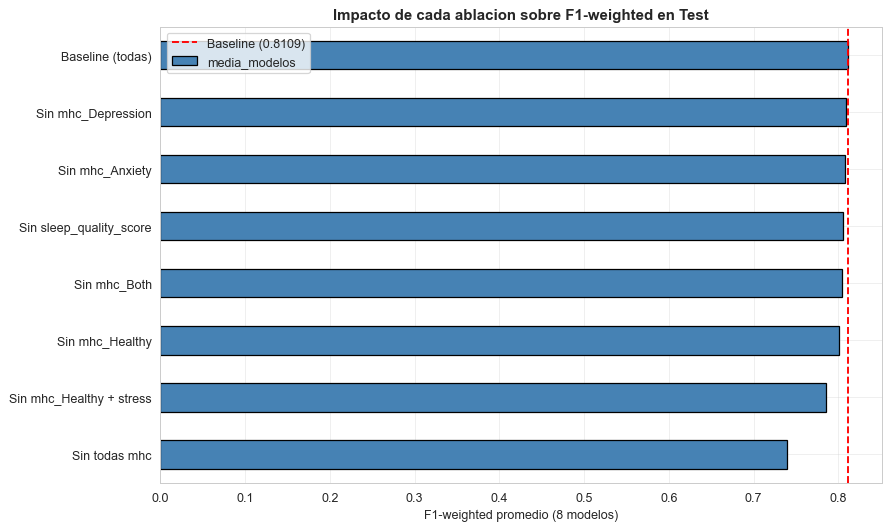

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
summary['media_modelos'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
baseline_val = summary.loc['Baseline (todas)', 'media_modelos']
ax.axvline(baseline_val, color='red', linestyle='--',
           label=f'Baseline ({baseline_val:.4f})')
ax.set_xlabel('F1-weighted promedio (8 modelos)')
ax.set_title('Impacto de cada ablacion sobre F1-weighted en Test', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 10.5 Conclusiones

- Un experimento con **delta cercano a 0** respecto al baseline indica que la feature/grupo eliminada era redundante o ruidosa.
- Un **delta negativo grande** (caida) revela que la feature era genuinamente informativa e independiente.
- Comparar `Sin mhc_Healthy` vs `Sin todas mhc`: si la caida es similar, el impacto de la variable viene casi solo de esa dummy; si es menor, las otras dummies tambien aportan.
- Las combinaciones (ej. `Sin mhc_Healthy + stress`) permiten detectar **redundancia entre features**: si quitar ambas juntas cae menos que la suma de caidas individuales, se solapaban en informacion.

## Conclusion Final

Notebook adaptado al dataset **Sleep Health (100k filas)** siguiendo CRISP-DM.

**Cambios clave vs Social Media:**
1. Pipeline reconstruido para 32 columnas con tipos correctos (numericas, ordinal `chronotype`, nominales).
2. Target `sleep_disorder_risk` (4 clases) con `LabelEncoder` ordenado.
3. Optimizaciones para 100k filas: muestra estratificada de 20k para CV, `LinearSVC`, `HistGradientBoosting`, `n_jobs=-1`, prints de progreso.
4. Evaluacion final siempre sobre test set completo.
5. Seccion 8 adaptada: comparacion sin `sleep_quality_score` (feature dominante).
